# To What Extent Do More Airbnb Reviews Reduce Pricing Inefficiency? Evidence from NYC Listings

 # Project 1

## 1.1 Introduction


Airbnb hosts set prices in markets where listings are differentiated by quality, location, and host characteristics, and where information is imperfect for both guests (about quality and trustworthiness) and hosts (about the “right” price). A large empirical literature uses hedonic pricing frameworks to show that Airbnb prices reflect structural listing characteristics, neighbourhood attributes, and broader spatial market structure, while also emphasizing that prices are not formed independently across space. In particular, spatial econometric work finds that nearby listings’ prices move together and that modelling spatial dependence is important for understanding short-term rental pricing (Gyódi & Nawaro, 2021; Boto-García et al., 2021). Recent studies further reinforce this point by showing that Airbnb prices are shaped by both property/service attributes and local-area conditions, including built-environment and transport-related factors, and that these effects can vary substantially across space and across the price distribution (Bernardi & Guidolin, 2023; Zhao, 2023).


A second strand of research emphasizes the role of platform information and reputation mechanisms. Reviews and ratings can reduce information asymmetries, and existing evidence shows that review-based measures, particularly written sentiment-based content, are meaningfully related to Airbnb prices (Lawani et al., 2019; Lin & Yang, 2024). More broadly, Airbnb prices and guest decisions also respond to other trust signals embedded in the platform. For example, Ert, Fleischer, and Magen (2016) demonstrate that hosts perceived as more trustworthy based on their photos charge higher prices and are more likely to be chosen, while standard review scores may become less informative when ratings are highly compressed. Related work on Airbnb screening behavior also highlights that platform design affects how hosts manage uncertainty. Mayya et al. (2021) show that hosts can trade off stricter screening for higher occupancy through Instant Book, illustrating how market outcomes depend on the interaction between platform mechanisms and information asymmetry.


A third strand of literature focuses on host concentration, professionalization, and market competition. Research on market structure shows that while city-level listing concentration may not always have a large direct effect on prices, hosts with larger listing shares can exert greater influence over pricing and compete differently from casual hosts (Bárcena-Martín, Benítez-Aurioles, & Pérez-Moreno, 2023). Similarly, Boto-García et al. (2021) find that spatial price mimicking differs between multi-host and single-host listings, while Abrate, Sainaghi, and Mauri (2022) show that professional hosts adopt more dynamic pricing strategies and display greater price variability than individual hosts. NYC-specific evidence also points in this direction: Voltes-Dorta (2025) finds that price competition among short-term Airbnb listings is weakened by the presence of multi-listing hosts following Local Law 18, suggesting that host concentration can shape local pricing dynamics even within the same city.


Building on these insights, this project reframes Airbnb pricing as a pricing-efficiency and learning question rather than simply asking what predicts higher prices. Existing studies show that prices depend on a multitude of factors, including listing attributes, neighbourhood effects, spatial interdependence, reputation signals, and host structure, but say less about whether ongoing market feedback helps hosts price more efficiently relative to close local comparables. Motivated especially by Lin and Yang’s (2024) emphasis on reviews as a mechanism for iterative price adjustment, I test whether review intensity (reviews_per_month) is associated with lower pricing inefficiency, measured as the absolute deviation from the neighbourhood × room_type benchmark price, and to what extent that relationship varies with the clarity of local market signals, proxied by comparable listing density. Overall, the evidence suggests that listings with higher review intensity tend to exhibit lower absolute mispricing, but that this relationship, while statistically significant, is economically modest and varies across market-density conditions.


Data: The primary dataset is the NYC Airbnb listings dataset, where the unit of observation is the individual listing. It contains listing prices, location identifiers (neighbourhood and borough), property type information, and review activity measures such as reviews_per_month. To account for broader safety differences across boroughs, I merge in 2019 NYPD complaint counts aggregated to the borough × law-category level and construct borough-level crime measures that are used as coarse location controls. I also merge in MTA subway-station data and construct a transit-access measure based on each listing’s distance to the nearest subway station. For the spatial analysis, I assign listings to MODZCTAs (Modified ZIP Code Tabulation Areas), which are NYC-specific ZIP-like geographic units used for mapping and public-health reporting. This allows the map section to aggregate listing-level outcomes to a smaller and more informative spatial unit than the borough level. For additional analysis, I also add scraped hotel-listing data from Hotels.com, aggregated to the borough level, in order to capture broader accommodation-market competition and compare hotel price levels with Airbnb prices.

Research question: To what extent is review intensity (reviews_per_month) associated with lower pricing inefficiency (absolute deviation from the neighbourhood × room_type benchmark price), and is this relationship stronger in markets with clearer price signals (higher comparable listing density)?


To operationalize pricing efficiency, I construct an outcome measure of pricing inefficiency defined as the absolute deviation between a listing’s price and the typical price for similar listings in the same local market segment:


Variables (X, Y, Z):


Y (Outcome: pricing inefficiency).
mispricing_abs = |price − median price within (neighbourhood, room_type)|.
This measures how far a listing’s price deviates from the typical price of close comparables. The absolute value captures magnitude of inefficiency (over- or under-pricing), and the median benchmark is robust to outliers and extreme listings. Using (neighbourhood, room_type) defines a realistic comparable set based on the two most salient market segments on Airbnb.


X (Main explanatory: review intensity / feedback flow).
reviews_per_month.
Interpreted as the rate of incoming feedback/transactions: more review activity means more opportunities for a host to update beliefs about demand and willingness-to-pay, which should reduce persistent deviations from the local benchmark.


Z (Mechanism proxy: clarity of local price signals):
Log_comp_density = log(1 + number of listings in the same (neighbourhood, room_type) cell)
When there are more comparable listings, the local “going rate” is easier to infer and less noisy; if learning is the mechanism, the negative association between reviews_per_month and mispricing_abs should be stronger when log_comp_density is higher.
Additional X variables:
minimum_nights and availability_365: capture booking frictions and usage patterns that can mechanically relate to review flow and pricing behavior.
number_of_reviews: captures accumulated reputation/tenure separately from the rate of new feedback.
calculated_host_listings_count: proxies host scale/market power and professionalization, which may relate to both pricing strategies and review activity.
borough-level crime measures (external merge): included to account for broad safety differences across boroughs that can shift baseline demand and prices; treated as a coarse location control (not a causal listing-level safety measure).
nearest_subway_km/log_nearest_subway_km: proxy transit accessibility. Listings closer to subway access may face different demand conditions, neighbourhood desirability, and pricing environments. I use the logged distance measure in the regressions as an additional location/accessibility control, while the level measure is used in maps and summary statistics.

In [167]:
#Setup cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys


In [168]:
df = pd.read_csv("../AB_NYC_2019.csv") 

## 1.2 Data Cleaning/Loading

In [169]:
# Make a working copy
df = df.copy()

# Ensure numeric price 
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Drop rows missing key fields for definitions
df = df.dropna(subset=["price", "neighbourhood", "room_type"])

# Trim extreme values
df = df[df["price"].between(10, 1000)]


**Create a Benchmark Price**:

In [170]:
bench = (
    df.groupby(["neighbourhood", "room_type"])["price"]
      .median()
      .rename("bench_price")
)

df = df.join(bench, on=["neighbourhood", "room_type"])
df["mispricing_abs"] = (df["price"] - df["bench_price"]).abs()

Create Z variable/mechanism:

In [171]:
density = (
    df.groupby(["neighbourhood", "room_type"])
      .size()
      .rename("comp_density")
)

df = df.join(density, on=["neighbourhood", "room_type"])
df["log_comp_density"] = np.log1p(df["comp_density"])

**Merge in Crime**:

In [172]:
crime = pd.read_csv("../crime_2019_boro_lawcat.csv")  


In [173]:
crime_piv = (
    crime.pivot(index="boro_nm", columns="law_cat_cd", values="n")
         .reset_index()
)

crime_piv.columns.name = None  

# rename to clearer variable names
crime_piv = crime_piv.rename(columns={
    "boro_nm": "neighbourhood_group",
    "FELONY": "crime_felony_2019",
    "MISDEMEANOR": "crime_misd_2019",
    "VIOLATION": "crime_viol_2019"
})

# map borough names to match airbnb neighbourhood_group
boro_map = {
    "MANHATTAN": "Manhattan",
    "BRONX": "Bronx",
    "BROOKLYN": "Brooklyn",
    "QUEENS": "Queens",
    "STATEN ISLAND": "Staten Island"
}
crime_piv["neighbourhood_group"] = crime_piv["neighbourhood_group"].map(boro_map)

crime_piv


,neighbourhood_group,crime_felony_2019,crime_misd_2019,crime_viol_2019
0,NaN,5,1,1
1,Bronx,28236,55336,16992
2,Brooklyn,43971,67422,20710
3,Manhattan,36332,64344,15148
4,Queens,29118,47489,15463
5,Staten Island,4668,10149,4096


In [174]:
df = df.merge(crime_piv, on="neighbourhood_group", how="left")

df[["crime_felony_2019","crime_misd_2019","crime_viol_2019"]].isna().mean()
df["crime_total_2019"] = df["crime_felony_2019"] + df["crime_misd_2019"] + df["crime_viol_2019"]


**Merge in transit**:

In [175]:
import pandas as pd
import numpy as np
import geopandas as gpd

# Load subway data
subway = pd.read_csv("../MTA_Subway_Stations.csv")
subway.columns = subway.columns.str.strip()
df.columns = df.columns.str.strip()

# Convert cleaned Airbnb sample to GeoDataFrame
airbnb_gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Convert subway stations to GeoDataFrame
subway_gdf = gpd.GeoDataFrame(
    subway,
    geometry=gpd.points_from_xy(subway["GTFS Longitude"], subway["GTFS Latitude"]),
    crs="EPSG:4326"
)

# Reproject both to NYC / Long Island feet-based CRS for distance calculation
airbnb_gdf = airbnb_gdf.to_crs("EPSG:2263")
subway_gdf = subway_gdf.to_crs("EPSG:2263")

# Keep only needed subway columns
subway_gdf = subway_gdf[["Stop Name", "Borough", "Line", "geometry"]]

# Find nearest subway station for each Airbnb listing
airbnb_nearest = gpd.sjoin_nearest(
    airbnb_gdf,
    subway_gdf,
    how="left",
    distance_col="nearest_subway_ft"
)

# Remove any duplicate listing ids created by nearest-match ties
airbnb_nearest = (
    airbnb_nearest
    .sort_values("id")
    .drop_duplicates(subset="id", keep="first")
    .copy()
)

# Convert feet to kilometers
airbnb_nearest["nearest_subway_km"] = airbnb_nearest["nearest_subway_ft"] * 0.0003048

# Logged version for later regressions
airbnb_nearest["log_nearest_subway_km"] = np.log1p(airbnb_nearest["nearest_subway_km"])

# Keep only the new transit variables plus listing id
transit = airbnb_nearest[["id", "nearest_subway_km", "log_nearest_subway_km"]].copy()

# Make sure transit itself is one row per listing
transit = transit.sort_values("id").drop_duplicates(subset="id", keep="first").copy()

# Drop old transit columns first if they already exist
df = df.drop(columns=["nearest_subway_km", "log_nearest_subway_km"], errors="ignore")

# Merge transit back into main dataframe
df = df.merge(transit, on="id", how="left")

# Make it one row per listing
df = df.sort_values("id").drop_duplicates(subset="id", keep="first").copy()




## 1.3 Summary Statistics Tables

In [176]:
from IPython.display import display

vars_main = [
    "mispricing_abs",
    "reviews_per_month",
    "log_comp_density",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "calculated_host_listings_count",
    "crime_total_2019",
    "nearest_subway_km"
]

label_map = {
    "mispricing_abs": "Absolute mispricing",
    "reviews_per_month": "Reviews/month",
    "log_comp_density": "Log comp. density",
    "minimum_nights": "Minimum nights",
    "availability_365": "Availability 365",
    "number_of_reviews": "Number of reviews",
    "calculated_host_listings_count": "Host listings count",
    "crime_total_2019": "Crime total (2019)",
    "nearest_subway_km": "Distance to subway (km)"
}

df_summary = df[vars_main].dropna().copy()

table1 = df_summary.describe().T[["count", "mean", "std", "min", "max"]]
table1 = table1.rename(columns={
    "count": "N",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Min",
    "max": "Max"
})

table1.index = table1.index.map(label_map)
table1 = table1.round(3)
table1["N"] = table1["N"].astype(int)

display(
    table1.style
    .format({
        "N": "{:d}",
        "Mean": "{:.3f}",
        "Std. Dev.": "{:.3f}",
        "Min": "{:.3f}",
        "Max": "{:.3f}",
    })
    .set_caption("Table 1. Summary Statistics")
)

print("Summary-table N:", len(df_summary))


,N,Mean,Std. Dev.,Min,Max
Absolute mispricing,38726,45.761,77.174,0.000,925.000
Reviews/month,38726,1.375,1.682,0.010,58.500
Log comp. density,38726,6.035,1.392,0.693,7.616
Minimum nights,38726,5.845,17.286,1.000,1250.000
Availability 365,38726,114.601,129.399,0.000,365.000
Number of reviews,38726,29.337,48.235,1.000,629.000
Host listings count,38726,5.172,26.334,1.000,327.000
Crime total (2019),38726,118790.520,15859.839,18913.000,132103.000
Distance to subway (km),38726,0.437,0.577,0.001,7.903


Summary-table N: 38726


Table 1 reports summary statistics for the main variables used in the analysis. Most listings have low review intensity (reviews_per_month concentrated near zero), and the outcome variable (mispricing_abs) shows a strong right tail, indicating a small number of listings with very large deviations from the neighbourhood × room_type benchmark. Overall, this motivates using visualizations (and binning) to summarize patterns rather than relying on raw scatter alone.


In [177]:
z = df_summary["log_comp_density"]
df_summary["Z_group"] = np.where(z <= z.median(), "Low Z", "High Z")

label_map = {
    "mispricing_abs": "Absolute mispricing",
    "reviews_per_month": "Reviews/month",
    "log_comp_density": "Log comp. density",
    "minimum_nights": "Minimum nights",
    "availability_365": "Availability 365",
    "number_of_reviews": "Number of reviews",
    "calculated_host_listings_count": "Host listings count",
    "crime_total_2019": "Crime total (2019)",
    "nearest_subway_km": "Distance to subway (km)"
}

def make_table(sub_df):
    t = sub_df[vars_main].describe().T[["count", "mean", "std", "min", "max"]]
    t = t.rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std. Dev.",
        "min": "Min",
        "max": "Max"
    })
    t.index = t.index.map(label_map)
    t = t.round(3)
    t["N"] = t["N"].astype(int)
    return t

table2_low = make_table(df_summary[df_summary["Z_group"] == "Low Z"])
table2_high = make_table(df_summary[df_summary["Z_group"] == "High Z"])

display(
    table2_low.style
    .format({
        "N": "{:d}",
        "Mean": "{:.3f}",
        "Std. Dev.": "{:.3f}",
        "Min": "{:.3f}",
        "Max": "{:.3f}",
    })
    .set_caption("Table 2a. Summary Statistics (Low Z)")
)

display(
    table2_high.style
    .format({
        "N": "{:d}",
        "Mean": "{:.3f}",
        "Std. Dev.": "{:.3f}",
        "Min": "{:.3f}",
        "Max": "{:.3f}",
    })
    .set_caption("Table 2b. Summary Statistics (High Z)")
)



,N,Mean,Std. Dev.,Min,Max
Absolute mispricing,19542,42.402,76.242,0.000,921.000
Reviews/month,19542,1.484,1.809,0.010,58.500
Log comp. density,19542,4.961,1.165,0.693,6.370
Minimum nights,19542,5.387,16.915,1.000,1250.000
Availability 365,19542,125.781,132.670,0.000,365.000
Number of reviews,19542,29.855,48.160,1.000,629.000
Host listings count,19542,6.562,34.488,1.000,327.000
Crime total (2019),19542,113496.553,19413.960,18913.000,132103.000
Distance to subway (km),19542,0.532,0.780,0.002,7.903


,N,Mean,Std. Dev.,Min,Max
Absolute mispricing,19184,49.182,77.965,0.000,925.000
Reviews/month,19184,1.264,1.533,0.010,14.000
Log comp. density,19184,7.129,0.399,6.433,7.616
Minimum nights,19184,6.312,17.643,1.000,999.000
Availability 365,19184,103.213,124.960,0.000,365.000
Number of reviews,19184,28.809,48.308,1.000,607.000
Host listings count,19184,3.755,13.580,1.000,327.000
Crime total (2019),19184,124183.280,8136.744,115824.000,132103.000
Distance to subway (km),19184,0.339,0.183,0.001,1.153


Tables 2a–2b split the sample by the competition proxy (Z = log_comp_density), where “High Z” represents neighbourhood × room_type cells with more comparable listings (clearer local price signals). Comparing means across the two groups provides an initial check for whether mispricing levels and review intensity differ systematically across more vs less information-rich markets.


## 1.4 Plots and Figures

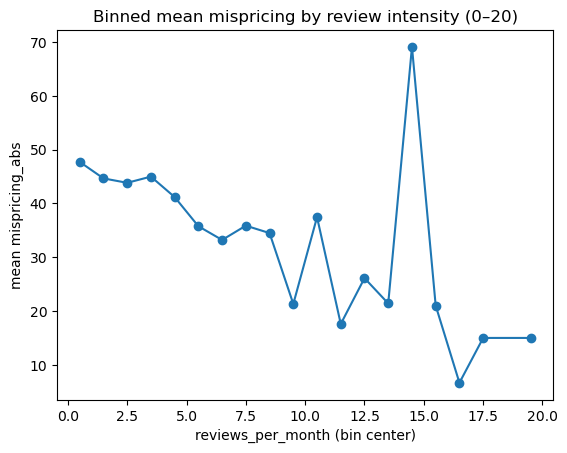

In [178]:
import numpy as np
import matplotlib.pyplot as plt
tmp = df[["reviews_per_month","mispricing_abs"]].dropna().copy()

tmp["rpm_bin"] = pd.cut(tmp["reviews_per_month"], bins=np.arange(0, 21, 1), right=False)
bin_means = tmp.groupby("rpm_bin", observed=True)["mispricing_abs"].mean()
x = [b.left + 0.5 for b in bin_means.index] 

plt.plot(x, bin_means.values, marker="o")
plt.title("Binned mean mispricing by review intensity (0–20)")
plt.xlabel("reviews_per_month (bin center)")
plt.ylabel("mean mispricing_abs")
plt.show()

Figure 1 shows mean mispricing_abs by 1-unit bins of reviews_per_month (0–20). The binned trend generally declines as review intensity increases, which is consistent with a “learning/pricing-efficiency” interpretation (more review activity is associated with smaller deviations from the benchmark). Isolated spikes at higher bins likely reflect small cell sizes (few listings with very high reviews_per_month).


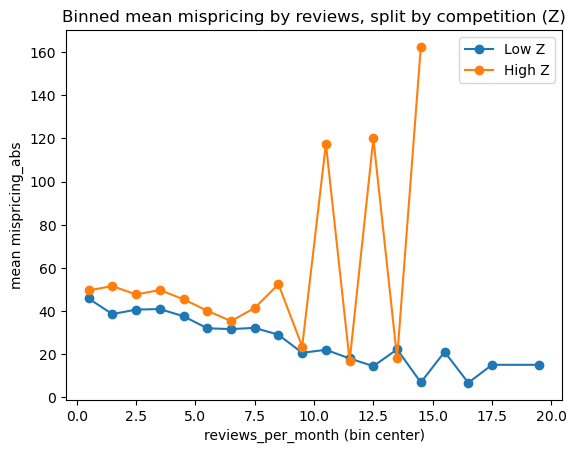

In [179]:
tmp = df[["reviews_per_month","mispricing_abs","log_comp_density"]].dropna().copy()
tmp["Z_group"] = pd.qcut(tmp["log_comp_density"], 2, labels=["Low Z", "High Z"])

for g in ["Low Z", "High Z"]:
    sub = tmp[tmp["Z_group"] == g].copy()
    sub["rpm_bin"] = pd.cut(sub["reviews_per_month"], bins=np.arange(0, 21, 1), right=False)
    bin_means = sub.groupby("rpm_bin", observed=True)["mispricing_abs"].mean()
    x = [b.left + 0.5 for b in bin_means.index]
    plt.plot(x, bin_means.values, marker="o", label=g)

plt.title("Binned mean mispricing by reviews, split by competition (Z)")
plt.xlabel("reviews_per_month (bin center)")
plt.ylabel("mean mispricing_abs")
plt.legend()
plt.show()

Figure 2 repeats the binned means separately for Low Z vs High Z markets. The Low Z group shows a smoother decline in mean mispricing with review intensity, while the High Z series is noisier at higher bins, suggesting instability from small counts and/or more heterogeneous conditions in dense markets. This provides descriptive (not causal) evidence that the review–mispricing relationship may differ across market structure.

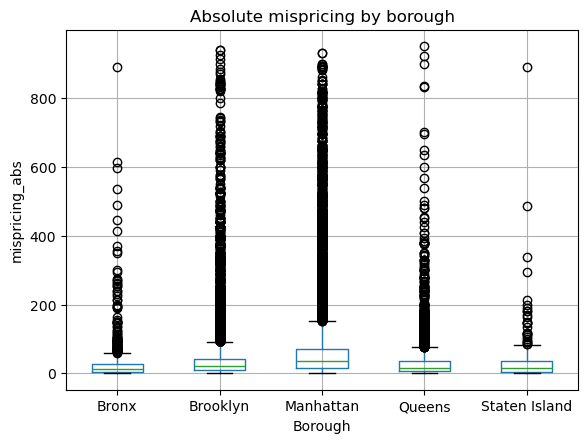

In [180]:
df.boxplot(column="mispricing_abs", by="neighbourhood_group")
plt.title("Absolute mispricing by borough")
plt.suptitle("")
plt.xlabel("Borough")
plt.ylabel("mispricing_abs")
plt.show()

Figure 3 compares the distribution of mispricing_abs across boroughs. Medians differ by borough and all boroughs exhibit heavy upper tails, indicating that location-level factors matter for pricing deviations even after benchmarking within neighbourhood × room_type. This motivates including broad location controls (e.g., borough indicators and borough-level covariates such as crime).

# Project 2

## 2.1 The Message

Listings with higher review intensity exhibit lower absolute pricing inefficiency on average, but the size of that relationship is economically modest. The negative relationship between reviews and mispricing is flatter in markets with higher comparable-listing density, suggesting that review-based learning is weaker, not stronger, where local price signals are already clearer.

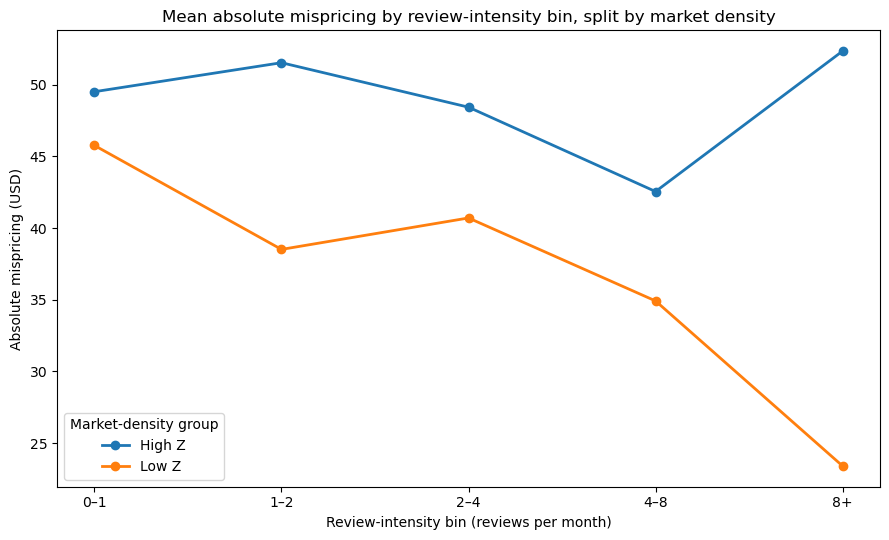

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the complete-case sample for the key message variables
msg_df = df[["mispricing_abs", "reviews_per_month", "log_comp_density"]].dropna().copy()

# Split markets by clarity of local price signals
msg_df["Z_group"] = np.where(
    msg_df["log_comp_density"] <= msg_df["log_comp_density"].median(),
    "Low Z",
    "High Z"
)

# Use broader review-intensity bins to reduce tail noise
bins = [0, 1, 2, 4, 8, np.inf]
labels = ["0–1", "1–2", "2–4", "4–8", "8+"]

msg_df["review_bin"] = pd.cut(
    msg_df["reviews_per_month"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Collapse to mean mispricing by review bin and market-density group
msg_plot = (
    msg_df.dropna(subset=["review_bin"])
    .groupby(["review_bin", "Z_group"], observed=True)
    .agg(
        mean_mispricing_abs=("mispricing_abs", "mean"),
        n=("mispricing_abs", "size")
    )
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))

for group, sub in msg_plot.groupby("Z_group", sort=False):
    ax.plot(
        sub["review_bin"].astype(str),
        sub["mean_mispricing_abs"],
        marker="o",
        linewidth=2,
        label=group
    )

ax.set_title("Mean absolute mispricing by review-intensity bin, split by market density")
ax.set_xlabel("Review-intensity bin (reviews per month)")
ax.set_ylabel("Absolute mispricing (USD)")
ax.legend(title="Market-density group")
plt.tight_layout()
plt.savefig("message_plot.png", dpi=300, bbox_inches="tight")
plt.show()

This figure plots mean absolute mispricing (in dollars) against binned reviews per month, separately for low- and high-density markets, where market density is defined using a median split of log comparable listing density. Using the complete-case sample, the plot shows that average pricing inefficiency generally declines as review intensity rises, which supports the message that listings with more ongoing feedback tend to be priced closer to the neighbourhood-by-room-type benchmark. At the same time, the gap between low- and high-density markets does not widen in the way originally hypothesized; if anything, the decline appears flatter in denser markets, which is consistent with the regression result that the review–mispricing relationship is weaker rather than stronger when comparable-listing density is higher.

## 2.2  Maps and Interpretations

In [182]:
import geopandas as gpd

# Load MODZCTA polygons
modzcta = gpd.read_file("../MODZCTA_2010_WGS1984.geo.json")

# Make sure CRS matches the listing points
modzcta = modzcta.to_crs("EPSG:4326")

# Convert df to listing points if needed
airbnb_points = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Spatial join: assign each listing to a MODZCTA
df_modzcta = gpd.sjoin(
    airbnb_points,
    modzcta,
    how="left",
    predicate="within"
)


In [183]:
zip_map_df = (
    df_modzcta
    .dropna(subset=["MODZCTA"])
    .groupby("MODZCTA", as_index=False)
    .agg(
        mean_mispricing_abs=("mispricing_abs", "mean"),
        mean_reviews_per_month=("reviews_per_month", "mean"),
        mean_log_comp_density=("log_comp_density", "mean"),
        mean_nearest_subway_km=("nearest_subway_km", "mean"),
        n_listings=("id", "count")
    )
)


In [184]:
modzcta_map = modzcta.merge(zip_map_df, on="MODZCTA", how="left")

map_gdf = modzcta_map.copy()
map_gdf = map_gdf[map_gdf["n_listings"] >= 20].copy()

In [185]:
import matplotlib.pyplot as plt

map_gdf = modzcta_map.copy()
map_gdf = map_gdf[map_gdf["n_listings"] >= 20].copy()


In [186]:
def make_map(gdf, column, title, cmap="viridis", filename=None):
    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column=column,
        ax=ax,
        legend=True,
        cmap=cmap,
        linewidth=0.2,
        edgecolor="white",
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "white",
            "hatch": "///",
            "label": "No data"
        }
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.axis("off")
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

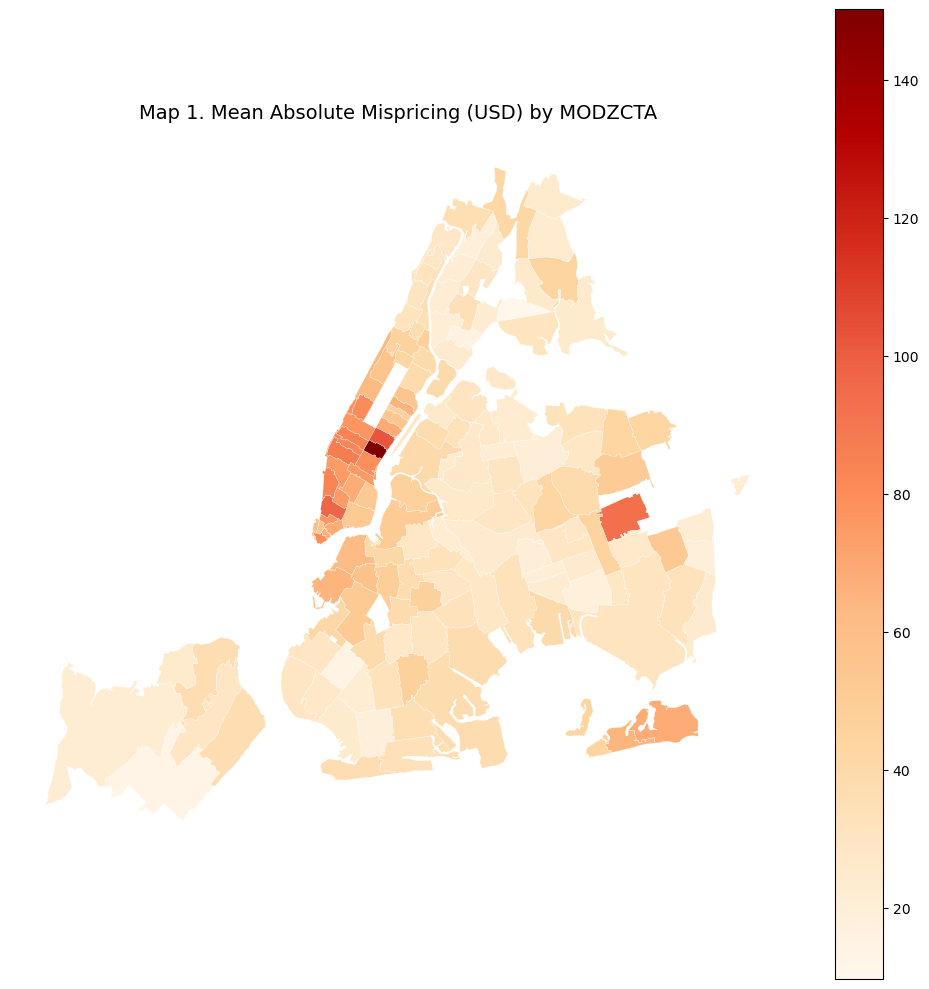

In [187]:
make_map(
    map_gdf,
    column="mean_mispricing_abs",
    title="Map 1. Mean Absolute Mispricing (USD) by MODZCTA",
    cmap="OrRd",
    filename="map1_mean_mispricing_abs.png"
)

Map 1 shows clear spatial heterogeneity in mean absolute mispricing across New York City. Higher average mispricing appears in parts of Manhattan, along with a few more isolated pockets in the outer boroughs, while many MODZCTAs in Brooklyn, Queens, and Staten Island display lower average deviations from the neighbourhood × room_type benchmark. This suggests that pricing inefficiency is not evenly distributed across space and may be shaped by local market conditions rather than by listing-level characteristics alone.

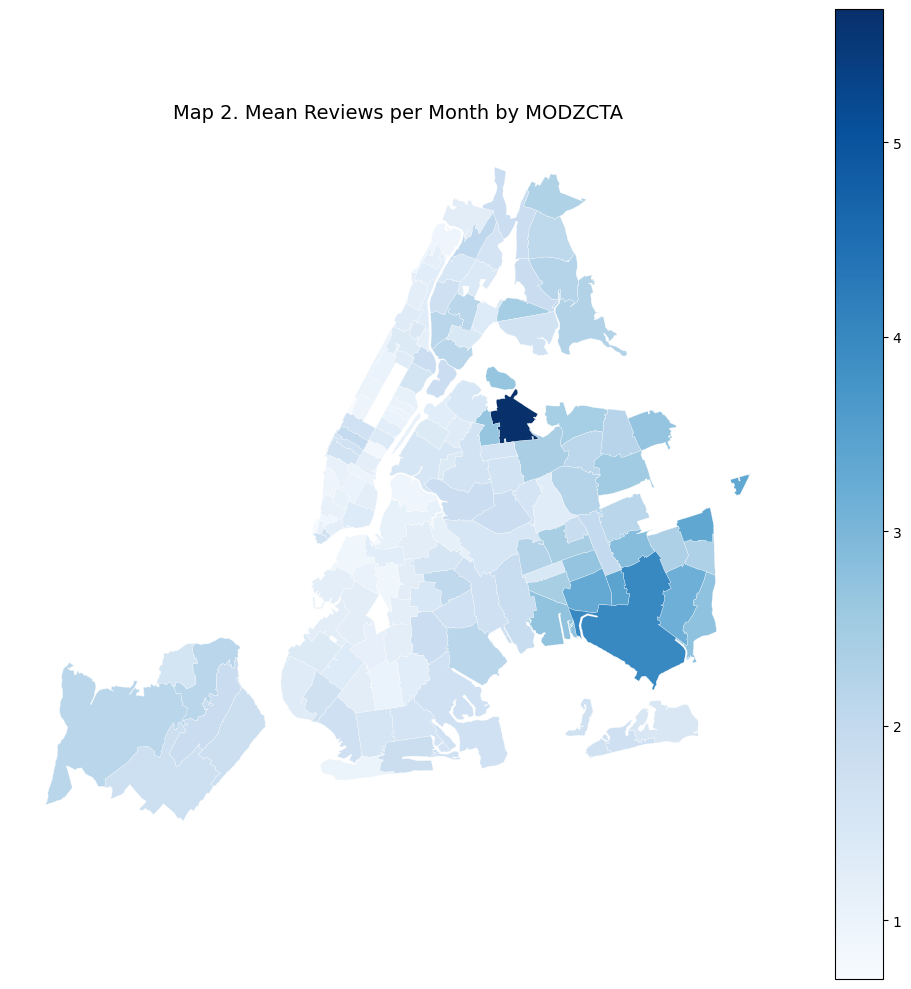

In [188]:
make_map(
    map_gdf,
    column="mean_reviews_per_month",
    title="Map 2. Mean Reviews per Month by MODZCTA",
    cmap="Blues",
    filename="map2_mean_reviews_per_month.png"
)

Map 2 indicates that review intensity also varies across space, although its pattern is less concentrated than the pattern for comparable-listing density. Some MODZCTAs in Queens and other selected parts of the city show relatively high average reviews per month, while many Manhattan and Brooklyn areas appear more moderate. This suggests that market feedback, as proxied by review intensity, is unevenly distributed across the city and does not map perfectly onto the areas with the highest mispricing.

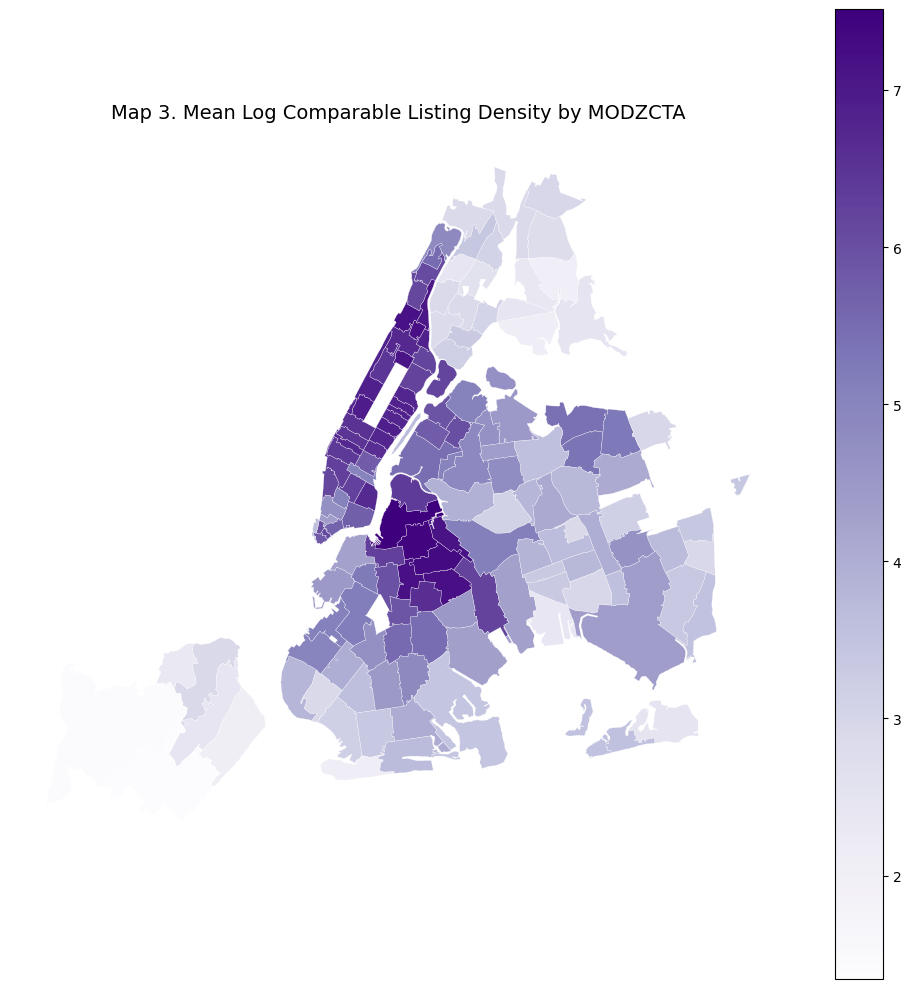

In [189]:
make_map(
    map_gdf,
    column="mean_log_comp_density",
    title="Map 3. Mean Log Comparable Listing Density by MODZCTA",
    cmap="Purples",
    filename="map3_mean_log_comp_density.png"
)

Map 3 displays the clearest spatial pattern of the four maps, using a logarithmic count of comparable listings. Comparable-listing density is highest in Manhattan and in parts of central Brooklyn, while it is substantially lower in Staten Island and in more peripheral sections of Queens and the Bronx. This is consistent with the idea that denser urban-core markets provide clearer local price signals, since hosts in those areas face a larger number of similar nearby listings from which to infer a going rate.

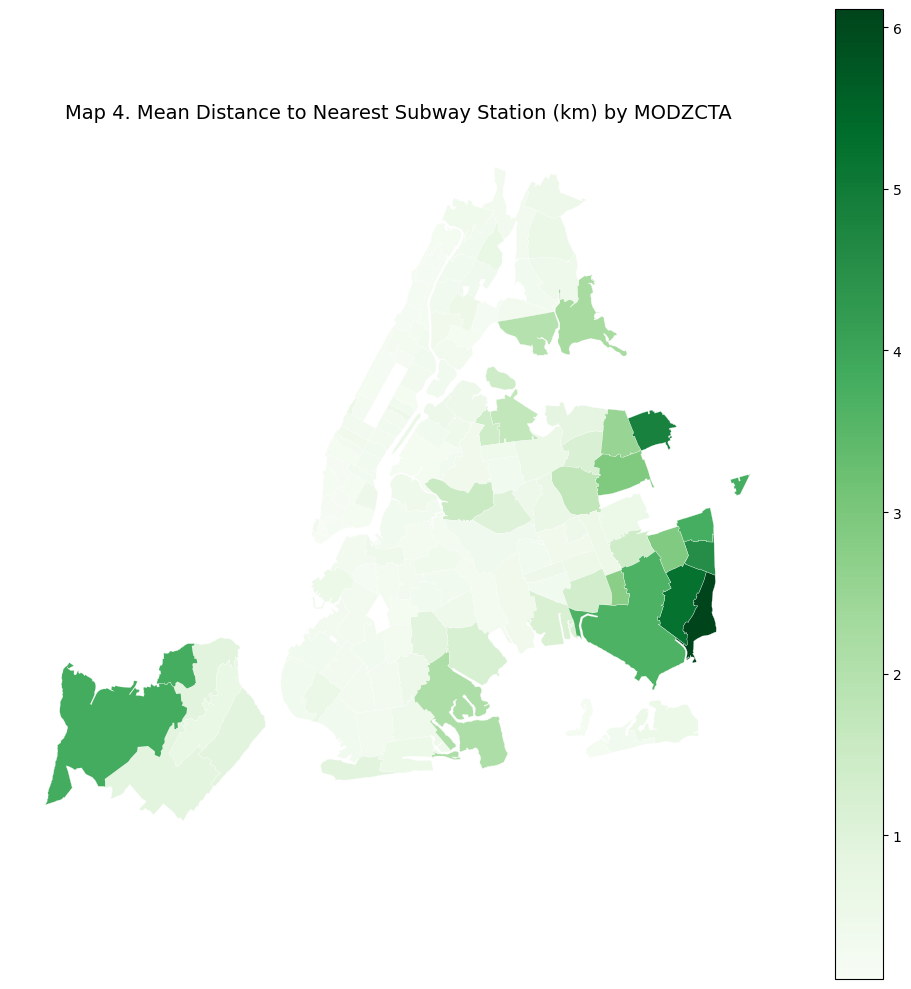

In [190]:
make_map(
    map_gdf,
    column="mean_nearest_subway_km",
    title="Map 4. Mean Distance to Nearest Subway Station (km) by MODZCTA",
    cmap="Greens",
    filename="map4_mean_nearest_subway_km.png"
)

Map 4 shows that distance to the nearest subway station is lowest in much of Manhattan and the inner-city core, and highest in Staten Island and farther-out parts of Queens. In other words, transit access is strongest in the dense central parts of the city and weakest in more peripheral areas. This pattern is broadly consistent with the idea that transit accessibility is another important spatial dimension of local market conditions, since areas farther from subway access may face different demand conditions and pricing environments.

Overall comparison across maps
These maps are intended as descriptive spatial diagnostics of the project’s main variables before moving to the regression analysis. Taken together, the four maps suggest that Airbnb pricing inefficiency, review intensity, comparable-market density, and transit accessibility all vary meaningfully across space, but they do not move one-for-one. The strongest and most intuitive spatial patterns appear in comparable-listing density and subway access, both of which are concentrated in the urban core. By contrast, the relationship between review intensity and mispricing appears more mixed geographically, which suggests that the review–mispricing relationship is unlikely to be explained by simple visual overlap alone. This spatial heterogeneity helps motivate the regression analysis, which can more directly test whether higher review intensity is associated with lower pricing inefficiency after accounting for market density, transit access, and other controls.

## 2.3 Regressions

In [191]:
# Regressions: benchmark + 8 models

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display, HTML
from stargazer.stargazer import Stargazer

# Start from one row per listing

reg_df = df.sort_values("id").drop_duplicates(subset="id", keep="first").copy()

# Create transformed variables for nonlinear specs
reg_df["log_reviews_pm"] = np.log1p(reg_df["reviews_per_month"])
reg_df["reviews_pm_sq"] = reg_df["reviews_per_month"] ** 2
reg_df["log_mispricing_abs"] = np.log1p(reg_df["mispricing_abs"])

# Use one common regression sample so N is comparable across models
reg_vars = [
    "id",
    "mispricing_abs",
    "log_mispricing_abs",
    "reviews_per_month",
    "log_reviews_pm",
    "reviews_pm_sq",
    "log_comp_density",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "calculated_host_listings_count",
    "crime_total_2019",
    "log_nearest_subway_km"
]

reg_df = reg_df[reg_vars].dropna().copy()


# Helper function for running OLS with robust standard errors
def fit_ols(formula, data):
    return smf.ols(formula=formula, data=data).fit(cov_type="HC1")


# FORMULAS


# Benchmark only 
f_bench = "mispricing_abs ~ reviews_per_month"

# Table 1: core linear sequence (4 regressions)
f1 = """
mispricing_abs ~ reviews_per_month + log_comp_density + minimum_nights
"""

f2 = """
mispricing_abs ~ reviews_per_month + log_comp_density + minimum_nights
                + availability_365
"""

f3 = """
mispricing_abs ~ reviews_per_month + log_comp_density + minimum_nights
                + availability_365 + number_of_reviews
"""

f4 = """
mispricing_abs ~ reviews_per_month + log_comp_density + minimum_nights
                + availability_365 + number_of_reviews
                + calculated_host_listings_count + crime_total_2019
"""

# Table 2: interaction / nonlinear / robustness (4 regressions)
f5 = """
mispricing_abs ~ reviews_per_month * log_comp_density
                + minimum_nights + availability_365 + number_of_reviews
                + calculated_host_listings_count + crime_total_2019
                + log_nearest_subway_km
"""

f6 = """
mispricing_abs ~ log_reviews_pm + log_comp_density
                + minimum_nights + availability_365 + number_of_reviews
                + calculated_host_listings_count + crime_total_2019
                + log_nearest_subway_km
"""

f7 = """
mispricing_abs ~ reviews_per_month + reviews_pm_sq + log_comp_density
                + minimum_nights + availability_365 + number_of_reviews
                + calculated_host_listings_count + crime_total_2019
                + log_nearest_subway_km
"""

f8 = """
log_mispricing_abs ~ log_reviews_pm + log_comp_density
                    + minimum_nights + availability_365 + number_of_reviews
                    + calculated_host_listings_count + crime_total_2019
                    + log_nearest_subway_km
"""

# Fit the models
m_bench = fit_ols(f_bench, reg_df)

m1 = fit_ols(f1, reg_df)
m2 = fit_ols(f2, reg_df)
m3 = fit_ols(f3, reg_df)
m4 = fit_ols(f4, reg_df)

m5 = fit_ols(f5, reg_df)
m6 = fit_ols(f6, reg_df)
m7 = fit_ols(f7, reg_df)
m8 = fit_ols(f8, reg_df)


# TABLE 1


stargazer1 = Stargazer([m_bench, m1, m2, m3, m4])
stargazer1.title("Table 3. OLS Regressions: Core Linear Specifications")
stargazer1.custom_columns(["Benchmark", "R1", "R2", "R3", "R4"], [1, 1, 1, 1, 1])
stargazer1.show_model_numbers(False)
stargazer1.rename_covariates({
    "Intercept": "Constant",
    "reviews_per_month": "Reviews per month",
    "log_comp_density": "Log comparable density",
    "minimum_nights": "Minimum nights",
    "availability_365": "Availability 365",
    "number_of_reviews": "Number of reviews",
    "calculated_host_listings_count": "Host listings count",
    "crime_total_2019": "Crime total (2019)"
})
stargazer1.add_line("Crime control", ["No", "No", "No", "No", "Yes"])
stargazer1.add_line("Transit control", ["No", "No", "No", "No", "No"])
stargazer1.add_line("Interaction included", ["No", "No", "No", "No", "No"])
stargazer1.add_line("Transformed X/Y", ["No", "No", "No", "No", "No"])

display(HTML(stargazer1.render_html()))


# TABLE 2


stargazer2 = Stargazer([m5, m6, m7, m8])
stargazer2.title("Table 4. OLS Regressions: Interaction, Nonlinearity, and Robustness")
stargazer2.custom_columns(["R5", "R6", "R7", "R8"], [1, 1, 1, 1])
stargazer2.show_model_numbers(False)
stargazer2.rename_covariates({
    "Intercept": "Constant",
    "reviews_per_month": "Reviews per month",
    "reviews_pm_sq": "Reviews per month squared",
    "log_reviews_pm": "Log(1 + reviews/month)",
    "log_comp_density": "Log comparable density",
    "reviews_per_month:log_comp_density": "Reviews × log density",
    "log_reviews_pm:log_comp_density": "Log reviews × log density",
    "minimum_nights": "Minimum nights",
    "availability_365": "Availability 365",
    "number_of_reviews": "Number of reviews",
    "calculated_host_listings_count": "Host listings count",
    "crime_total_2019": "Crime total (2019)",
    "log_nearest_subway_km": "Log distance to subway (km)",
})
stargazer2.add_line("Crime control", ["Yes", "Yes", "Yes", "Yes"])
stargazer2.add_line("Transit control", ["Yes", "Yes", "Yes", "Yes"])
stargazer2.add_line("Interaction included", ["Yes", "No", "No", "No"])
stargazer2.add_line("Transformed X/Y", ["No", "X only", "Quadratic X", "X and Y"])

display(HTML(stargazer2.render_html()))

### Preferred Regression Specification

My preferred regression is:

```text
Absolute pricing inefficiency
= β0
+ β1(Review intensity)
+ β2(Log comparable listing density)
+ β3(Review intensity × Log comparable listing density)
+ β4(Minimum nights)
+ β5(Availability)
+ β6(Number of reviews)
+ β7(Host listing count)
+ β8(Crime control)
+ β9(Log distance to subway)
+ ε

I treat this as my preferred specification because it matches my research question most directly. The dependent variable is absolute pricing inefficiency, measured as the absolute deviation between a listing’s price and the neighbourhood-by-room-type benchmark. The main explanatory variable is review intensity, measured by reviews per month. I include log comparable listing density as the mechanism variable because my hypothesis is that the relationship between review intensity and pricing inefficiency should depend on how clear local market signals are. The interaction term tests whether the relationship between review intensity and pricing inefficiency is stronger in denser comparable markets. I also include controls for minimum nights, availability, number of reviews, host listing count, crime, and distance to the nearest subway station to account for booking frictions, host scale, safety differences, and transit accessibility. Among the specifications in Table 4, this model (R5) is my preferred model because it provides the most direct test of my main hypothesis by including review intensity, comparable listing density, their interaction, and the full set of controls, while remaining economically interpretable.

**Regression interpretation**
Table 3 shows a consistent negative association between review intensity and pricing inefficiency. Across the benchmark and core linear specifications, the coefficient on reviews per month remains negative and statistically significant, even after adding log comparable listing density, listing controls, host controls, and the borough-level crime control. In substantive terms, the estimates imply that one additional review per month is associated with roughly 0.85 to 2.66 dollars lower absolute mispricing, depending on specification. This suggests that review activity is linked to modest but meaningful improvements in pricing efficiency, measured as smaller deviations from the neighbourhood × room_type benchmark price. At the same time, the low R-squared values indicate that reviews explain only a small share of the total variation in mispricing, which is consistent with the idea that Airbnb pricing is also shaped by many listing-specific and unobserved factors.

Table 4 adds interaction, nonlinearity, and robustness checks. The most notable result is that the interaction between reviews per month and log comparable listing density is positive and statistically significant, which goes against the original hypothesis that clearer local price signals would strengthen the review-based learning effect. Instead, the negative association between reviews and mispricing appears to become weaker in denser comparable markets. Using the interaction estimates, the implied effect of one additional review per month is about 0.83 dollars lower absolute mispricing in lower-density markets, but only about 0.19 dollars lower absolute mispricing in higher-density markets. The logged-review specification still produces a negative and significant coefficient, which is more consistent with a diminishing-returns interpretation: the first additional reviews appear to provide more useful pricing feedback than later ones. In that specification, doubling reviews per month is associated with roughly 1.7 dollars lower absolute mispricing. By contrast, the quadratic term on reviews is small and statistically weak, so the evidence for a simple polynomial nonlinearity is limited.

Taken together, the regression results suggest that Airbnb reviews do appear to help hosts price more efficiently, but the extent of that relationship is economically modest and depends on market context. In level terms, the effect is generally small, amounting to about 1 to 3 dollars less absolute mispricing per additional review per month in the simpler linear models and less than 1 dollar in the fuller controlled specifications. In proportional terms, the log-log robustness model implies that a 10 percent increase in reviews per month is associated with about a 1 percent decrease in absolute mispricing, while doubling review intensity is associated with about a 6.7 percent decrease in mispricing. A reasonable summary, then, is that more reviews are associated with lower mispricing on average, but the size of that effect is fairly modest and does not become stronger in denser markets. This means the paper’s main finding is supported, while the proposed mechanism is not: review activity is linked to lower pricing inefficiency, but comparable-listing density does not seem to amplify that relationship.

# Final Project

## Web Scraping

## 3.1 Potential Data to Scrape 

A useful addition to this project is borough-level hotel competition data scraped from Hotels.com result pages for New York City. The main Airbnb dataset contains rich information on listing prices, review activity, host scale, and local within-platform competition, but it does not capture the broader accommodation market that Airbnb hosts may also be competing against. Scraping hotel listings helps extend the analysis beyond Airbnb itself by adding a measure of formal hotel competition and hotel price levels across boroughs. I scrape hotel names, borough labels, guest scores, review counts, and displayed total prices from Hotels.com search-result pages for Manhattan, Brooklyn, the Bronx, Queens-related subpages, and Staten Island. Because these hotel pages provide borough information more reliably than full geocoded addresses, I aggregate the scraped hotel data to the borough level and merge it with the Airbnb data using the existing neighbourhood_group variable. This allows me to construct new variables such as hotel count by borough, mean hotel total price by borough, and the hotel–Airbnb price gap by borough. These measures help answer the research question by showing whether Airbnb pricing inefficiency may be related not only to review-based learning and comparable listing density within Airbnb, but also to the broader price and competition conditions of the local accommodation market.

## 3.2 Potential Challenges

There are several challenges in scraping hotel competition data from Hotels.com for this project. First, the website is not easy to scrape directly through repeated live requests, since those requests triggered rate-limiting errors, so I instead worked with saved HTML pages downloaded manually from the site. This means the scraping process is feasible, but not in the simplest automated form. Second, the pricing information exposed in the saved HTML is not perfectly consistent across hotel cards. In particular, displayed total prices were captured much more reliably than nightly prices, so the borough-level hotel price measures are based primarily on total posted prices rather than nightly base rates. Third, coverage is not perfectly balanced across boroughs, especially for Queens, where some saved subpages yielded very few usable rows. As a result, the scraped hotel variables should be interpreted as coarse borough-level competition measures rather than complete census-style measures of the NYC hotel market. A further challenge is that hotel prices on the website are inherently time-dependent: they reflect a particular search date, stay window, and booking configuration rather than a permanent hotel price. For that reason, if this project were extended in the future, the scraping program could be run repeatedly over time to build a richer panel of hotel price snapshots. For the purposes of this project, however, scraping a cross-sectional snapshot is still useful because it allows me to visualize and compare the broader accommodation market across boroughs. Even though I could not cleanly scrape every part of the source in real time, I was still able to scrape a meaningful subset of hotel listings, construct borough-level measures of hotel competition and hotel prices, and use them to motivate the relationship between Airbnb pricing inefficiency and the broader local accommodation market.

 ## 3.3 Scraping Data From a Website

In [192]:
import re
import pandas as pd

BOROUGHS = {"Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"}

def clean_money(x):
    if x is None:
        return None
    return float(str(x).replace(",", "").strip())

def clean_reviews(x):
    if x is None:
        return None
    return int(str(x).replace(",", "").strip())

def is_date_line(x):
    return bool(re.search(r"[A-Z][a-z]{2},? [A-Z][a-z]{2} \d{1,2}", x)) or bool(
        re.search(r"[A-Z][a-z]{2} \d{1,2}\s*[–-]\s*[A-Z][a-z]{2} \d{1,2}", x)
    )

def looks_like_hotel_name(x):
    bad_substrings = [
        "out of 10", "reviews", "The price is", " total", "CAD", "$",
        "Properties in", "Hotel Search results", "Skip to", "Shop travel",
        "Deals", "Gift Cards", "Rewards", "Open app", "List your property",
        "Support", "Trips", "Sign in", "Sign up", "Where to?", "Dates",
        "Choose dates", "See all", "Map", "VIP", "Member", "Save", "Reserve",
        "Book", "Search", "filters", "Popular locations", "Amenities",
        "Collect stamps"
    ]

    bad_exact = {
        "exceptional", "wonderful", "very good", "good", "excellent",
        "collect stamps"
    }

    x_clean = x.lower().strip()

    if x_clean in bad_exact:
        return False
    if x in BOROUGHS:
        return False
    if is_date_line(x):
        return False
    if any(b.lower() in x.lower() for b in bad_substrings):
        return False
    if re.fullmatch(r"[\d,]+", x):
        return False
    if len(x) < 4:
        return False
    return True

def parse_hotels_from_text(text, source_url):
    lines = [re.sub(r"\s+", " ", ln).strip() for ln in text.splitlines()]
    lines = [ln for ln in lines if ln]

    rows = []

    total_idx = [
        i for i, ln in enumerate(lines)
        if re.search(r"[A-Z]{0,2}\s*\$ ?[\d,]+ total", ln)
    ]

    for i in total_idx:
        prev_window = lines[max(0, i - 20):i]
        next_window = lines[i:min(len(lines), i + 8)]

        # total price
        total_price = None
        m_total = re.search(r"[A-Z]{0,2}\s*\$ ?([\d,]+) total", lines[i])
        if m_total:
            total_price = clean_money(m_total.group(1))


        # guest score
        guest_score = None
        for w in reversed(prev_window):
            m = re.search(r"(\d+(?:\.\d+)?) out of 10", w)
            if m:
                guest_score = float(m.group(1))
                break

        # review count
        review_count = None
        for w in reversed(prev_window):
            m = re.search(r"\(?([\d,]+) reviews?\)?", w)
            if m:
                review_count = clean_reviews(m.group(1))
                break

        # borough and its position
        borough = None
        borough_pos = None
        for j, w in enumerate(prev_window):
            for b in BOROUGHS:
                if w == b:
                    borough = b
                    borough_pos = j
                    break
            if borough is not None:
                break

        # hotel name
        hotel_name = None
        if borough_pos is not None:
            candidate_lines = prev_window[:borough_pos]
        else:
            candidate_lines = prev_window

        for w in reversed(candidate_lines):
            if looks_like_hotel_name(w):
                hotel_name = w
                break

        rows.append({
            "hotel_name": hotel_name,
            "borough": borough,
            "guest_score": guest_score,
            "review_count": review_count,
            "total_price": total_price,
            "source_url": source_url
        })

    out = pd.DataFrame(rows)

    if len(out) == 0:
        return out

    out = out.dropna(subset=["hotel_name", "borough", "total_price"]).copy()
    out = out[out["borough"].isin(BOROUGHS)].copy()
    out["hotel_name"] = out["hotel_name"].str.strip()
    out = out.drop_duplicates(subset=["hotel_name", "borough", "total_price"])

    return out

This code block defines the helper functions used to clean and parse the saved Hotels.com HTML pages. The goal is to identify hotel names, borough labels, guest scores, review counts, and displayed total prices from the raw page text. Because the page structure is noisy and not designed for simple copying, these helper functions are needed to isolate hotel-card information from surrounding text such as filters, page labels, and marketing content.

In [193]:
from pathlib import Path
from bs4 import BeautifulSoup
import pandas as pd

html_dir = Path("hotels_html")

html_files = [
    "manhattan_hotels.html",
    "brooklyn_hotels.html",
    "bronx_hotels.html",
    "queens_lic_hotels.html",
    "queens_flushing_hotels.html",
    "queens_jamaica_hotels.html",
    "staten_island_hotels.html",
]

hotel_frames = []

for file_name in html_files:
    file_path = html_dir / file_name

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            html = f.read()

        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text("\n", strip=True)

        tmp = parse_hotels_from_text(text, str(file_path))

        if not tmp.empty:
            hotel_frames.append(tmp)
            print(f"Parsed {len(tmp)} rows from {file_name}")
        else:
            print(f"No rows found in {file_name}")

    except Exception as e:
        print(f"Failed on {file_name}: {e}")

hotels_raw = pd.concat(hotel_frames, ignore_index=True) if hotel_frames else pd.DataFrame()
hotels_raw.head()

Parsed 27 rows from manhattan_hotels.html
Parsed 68 rows from brooklyn_hotels.html
Parsed 15 rows from bronx_hotels.html
No rows found in queens_lic_hotels.html
No rows found in queens_flushing_hotels.html
Parsed 2 rows from queens_jamaica_hotels.html
Parsed 6 rows from staten_island_hotels.html


,hotel_name,borough,guest_score,review_count,total_price,source_url
0,Conrad New York Downtown,Manhattan,9.6,1002.0,515.0,hotels_html/manhattan_hotels.html
1,The Times Square EDITION,Manhattan,9.2,1000.0,762.0,hotels_html/manhattan_hotels.html
2,Equinox Hotel New York,Manhattan,9.2,822.0,1453.0,hotels_html/manhattan_hotels.html
3,Night Hotel Broadway,Manhattan,7.4,2915.0,297.0,hotels_html/manhattan_hotels.html
4,The Wallace,Manhattan,9.8,1108.0,845.0,hotels_html/manhattan_hotels.html


This block reads the saved HTML files for each borough page and applies the parsing function to each one. I use locally saved HTML rather than repeated live requests because the website triggered rate-limiting errors during direct scraping. The output of this step is a raw hotel-level dataset containing the listings that could be successfully extracted from each page.

In [194]:
hotels = hotels_raw.copy()

hotels = hotels.dropna(subset=["hotel_name", "borough", "total_price"]).copy()

valid_boroughs = ["Manhattan", "Brooklyn", "Bronx", "Queens", "Staten Island"]
hotels = hotels[hotels["borough"].isin(valid_boroughs)].copy()

hotels = hotels.drop_duplicates(subset=["hotel_name", "borough", "total_price"]).copy()

print(hotels["borough"].value_counts(dropna=False))
hotels.head()

borough
Brooklyn         61
Manhattan        34
Bronx            15
Staten Island     6
Queens            2
Name: count, dtype: int64


,hotel_name,borough,guest_score,review_count,total_price,source_url
0,Conrad New York Downtown,Manhattan,9.6,1002.0,515.0,hotels_html/manhattan_hotels.html
1,The Times Square EDITION,Manhattan,9.2,1000.0,762.0,hotels_html/manhattan_hotels.html
2,Equinox Hotel New York,Manhattan,9.2,822.0,1453.0,hotels_html/manhattan_hotels.html
3,Night Hotel Broadway,Manhattan,7.4,2915.0,297.0,hotels_html/manhattan_hotels.html
4,The Wallace,Manhattan,9.8,1108.0,845.0,hotels_html/manhattan_hotels.html


This block cleans the raw scraped hotel data by removing incomplete rows, restricting the sample to the five NYC boroughs, and dropping duplicate hotel entries. This is necessary because the scraped HTML is not perfectly uniform across pages, and some borough pages yielded uneven coverage. After cleaning, the hotel data are better suited for borough-level aggregation.

In [195]:
hotel_boro = (
    hotels.groupby("borough", as_index=False)
    .agg(
        hotel_count_boro=("hotel_name", "nunique"),
        mean_hotel_total_price_boro=("total_price", "mean"),
        median_hotel_total_price_boro=("total_price", "median"),
        mean_hotel_score_boro=("guest_score", "mean"),
        mean_hotel_review_count_boro=("review_count", "mean")
    )
)

hotel_boro


,borough,hotel_count_boro,mean_hotel_total_price_boro,median_hotel_total_price_boro,mean_hotel_score_boro,mean_hotel_review_count_boro
0,Bronx,15,323.800000,318.0,7.880000,898.866667
1,Brooklyn,60,596.819672,457.0,7.829508,862.622951
2,Manhattan,32,758.882353,569.0,8.793939,1836.424242
3,Queens,2,406.500000,406.5,7.900000,2797.500000
4,Staten Island,6,406.666667,279.0,7.833333,957.500000


In [196]:
airbnb_boro = (
    df.groupby("neighbourhood_group", as_index=False)
    .agg(
        airbnb_listing_count_boro=("id", "nunique"),
        mean_airbnb_price_boro=("price", "mean"),
        median_airbnb_price_boro=("price", "median"),
        mean_airbnb_mispricing_boro=("mispricing_abs", "mean")
    )
)

airbnb_boro

,neighbourhood_group,airbnb_listing_count_boro,mean_airbnb_price_boro,median_airbnb_price_boro,mean_airbnb_mispricing_boro
0,Bronx,1089,85.361800,65.0,28.334252
1,Brooklyn,20041,117.860835,90.0,40.137917
2,Manhattan,21488,178.944620,149.0,64.438757
3,Queens,5656,95.008310,75.0,32.182638
4,Staten Island,371,98.584906,75.0,31.339623


The next step is to convert both the scraped hotel data and the Airbnb data into comparable borough-level summaries. Here, hotel_boro aggregates the scraped hotel sample by borough and produces measures such as hotel count, mean hotel total price, median hotel total price, average guest score, and average review count. airbnb_boro does the same for the Airbnb data, summarizing listing counts, mean and median Airbnb prices, and average mispricing by borough. These two summary tables make it possible to compare the formal hotel market and the Airbnb market on a common geographic level.

In [197]:
comparison_boro = airbnb_boro.merge(
    hotel_boro,
    left_on="neighbourhood_group",
    right_on="borough",
    how="left"
)

comparison_boro["hotel_airbnb_total_gap_boro"] = (
    comparison_boro["mean_hotel_total_price_boro"] - comparison_boro["mean_airbnb_price_boro"]
)

comparison_boro["hotel_to_airbnb_total_ratio_boro"] = (
    comparison_boro["mean_hotel_total_price_boro"] / comparison_boro["mean_airbnb_price_boro"]
)

comparison_boro

comparison_boro_display = comparison_boro[
    [
        "neighbourhood_group",
        "hotel_count_boro",
        "mean_hotel_total_price_boro",
        "mean_airbnb_price_boro",
        "hotel_airbnb_total_gap_boro"
    ]
].copy()

comparison_boro_display = comparison_boro_display.rename(columns={
    "neighbourhood_group": "Borough",
    "hotel_count_boro": "Hotel count",
    "mean_hotel_total_price_boro": "Mean hotel total price",
    "mean_airbnb_price_boro": "Mean Airbnb price",
    "hotel_airbnb_total_gap_boro": "Hotel–Airbnb price gap"
})

comparison_boro_display = comparison_boro_display.round(2)
comparison_boro_display

,Borough,Hotel count,Mean hotel total price,Mean Airbnb price,Hotel–Airbnb price gap
0,Bronx,15,323.80,85.36,238.44
1,Brooklyn,60,596.82,117.86,478.96
2,Manhattan,32,758.88,178.94,579.94
3,Queens,2,406.50,95.01,311.49
4,Staten Island,6,406.67,98.58,308.08


I then merge these borough summaries into comparison_boro, which directly compares hotel and Airbnb conditions across boroughs. From this merged table, I construct variables such as the hotel–Airbnb total price gap and the hotel-to-Airbnb price ratio. Finally, I merge the selected borough-level hotel variables back into the main Airbnb dataset using neighbourhood_group, so that each Airbnb listing inherits the broader accommodation-market conditions of its borough without dropping observations from the main sample.

In [198]:
df = df.merge(
    comparison_boro[
        [
            "neighbourhood_group",
            "hotel_count_boro",
            "mean_hotel_total_price_boro",
            "median_hotel_total_price_boro",
            "mean_hotel_score_boro",
            "mean_hotel_review_count_boro",
            "hotel_airbnb_total_gap_boro",
            "hotel_to_airbnb_total_ratio_boro"
        ]
    ],
    on="neighbourhood_group",
    how="left"
)

df[
    [
        "neighbourhood_group",
        "hotel_count_boro",
        "mean_hotel_total_price_boro",
        "hotel_airbnb_total_gap_boro"
    ]
].drop_duplicates().sort_values("neighbourhood_group")

,neighbourhood_group,hotel_count_boro,mean_hotel_total_price_boro,hotel_airbnb_total_gap_boro
171,Bronx,15,323.800000,238.438200
0,Brooklyn,60,596.819672,478.958837
1,Manhattan,32,758.882353,579.937733
46,Queens,2,406.500000,311.491690
169,Staten Island,6,406.666667,308.081761


## 3.4 Visualizing the Scraped Dataset

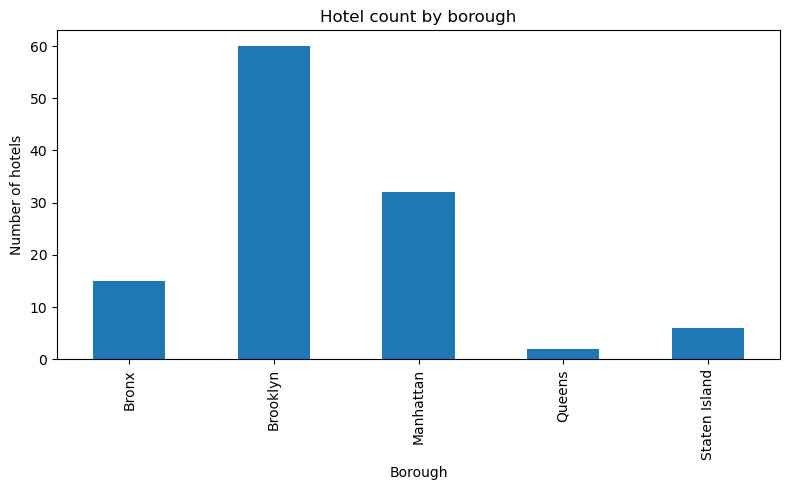

In [199]:
comparison_boro.plot(
    x="neighbourhood_group",
    y="hotel_count_boro",
    kind="bar",
    legend=False,
    figsize=(8, 5),
    title="Hotel count by borough"
)
plt.xlabel("Borough")
plt.ylabel("Number of hotels")
plt.tight_layout()
plt.show()

This figure shows that the scraped hotel sample is concentrated mainly in Brooklyn and Manhattan, with more limited coverage in the Bronx and Staten Island and especially weak coverage in Queens. In substantive terms, this suggests that formal hotel competition is not evenly distributed across boroughs in the scraped sample, which is consistent with the idea that Airbnb hosts in some boroughs face a denser non-Airbnb accommodation market than others. At the same time, the low Queens count means that any conclusions for Queens should be interpreted cautiously. Overall, the figure supports the broader project by showing that the external accommodation market varies across space, which may help explain differences in Airbnb pricing behavior beyond within-platform review signals alone.

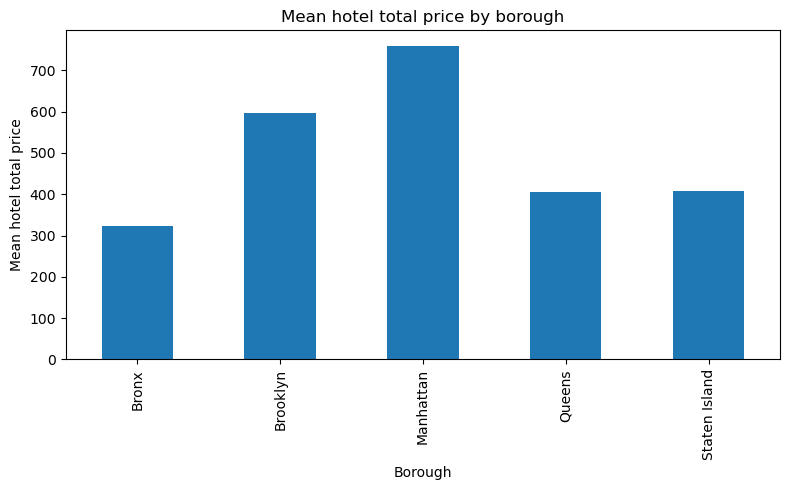

In [200]:
comparison_boro.plot(
    x="neighbourhood_group",
    y="mean_hotel_total_price_boro",
    kind="bar",
    legend=False,
    figsize=(8, 5),
    title="Mean hotel total price by borough"
)
plt.xlabel("Borough")
plt.ylabel("Mean hotel total price")
plt.tight_layout()
plt.show()

This figure shows that mean hotel total prices are highest in Manhattan, followed by Brooklyn, and lower in the Bronx, Queens, and Staten Island. This pattern is economically intuitive because Manhattan represents the highest-priced core accommodation market in the city, while outer-borough hotel markets appear cheaper on average in the scraped sample. For the project, this matters because Airbnb hosts are likely pricing against different outside options depending on borough: a host in Manhattan faces a much more expensive hotel market than a host in the Bronx. This means that Airbnb pricing inefficiency may reflect not only review-based learning and comparable listing density within Airbnb, but also the broader price level of local hotel competition.

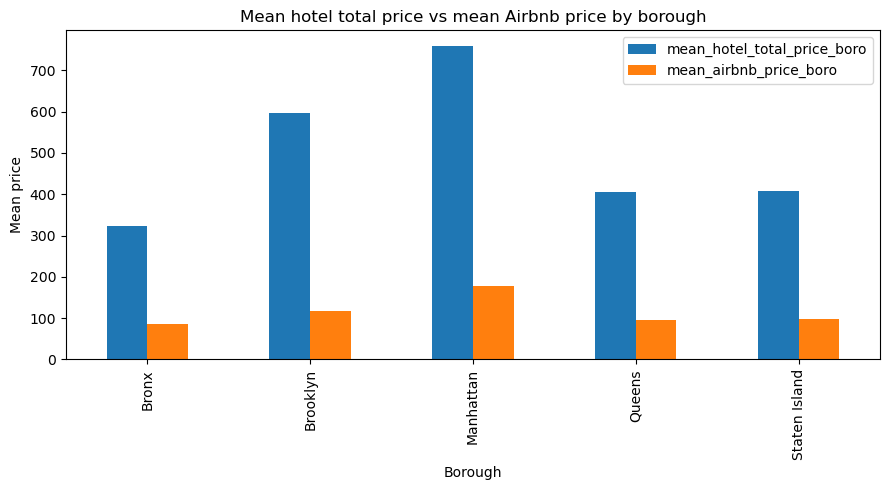

In [201]:
plot_df = comparison_boro[
    ["neighbourhood_group", "mean_hotel_total_price_boro", "mean_airbnb_price_boro"]
].set_index("neighbourhood_group")

plot_df.plot(
    kind="bar",
    figsize=(9, 5),
    title="Mean hotel total price vs mean Airbnb price by borough"
)
plt.xlabel("Borough")
plt.ylabel("Mean price")
plt.tight_layout()
plt.savefig("hotel_vs_airbnb_price_by_borough.png", dpi=300, bbox_inches="tight")
plt.show()

This comparison shows that mean scraped hotel total prices exceed mean Airbnb prices in every borough in the current sample. The size of the difference is especially large in Manhattan and Brooklyn, where hotels appear much more expensive than Airbnb on average. This suggests that Airbnb may offer a relatively cheaper alternative to the formal hotel market across New York City, although the exact size of the gap should still be interpreted cautiously because hotel prices are based on a scraped snapshot and Queens coverage is limited. In relation to the research question, this figure adds useful context by showing that Airbnb listings are priced within a broader accommodation market where the outside option, hotels, is often substantially more expensive.

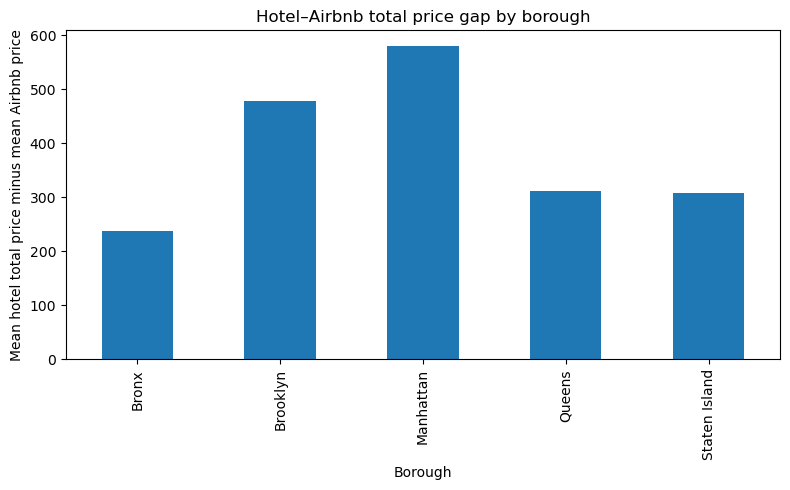

In [202]:
comparison_boro.plot(
    x="neighbourhood_group",
    y="hotel_airbnb_total_gap_boro",
    kind="bar",
    legend=False,
    figsize=(8, 5),
    title="Hotel–Airbnb total price gap by borough"
)
plt.xlabel("Borough")
plt.ylabel("Mean hotel total price minus mean Airbnb price")
plt.tight_layout()
plt.show()

This figure summarizes the same comparison in gap form by plotting the difference between mean hotel total prices and mean Airbnb prices across boroughs. The gap is largest in Manhattan, followed by Brooklyn, which implies that Airbnb listings in those boroughs are operating in especially high-priced formal accommodation markets. Smaller but still positive gaps in the Bronx, Queens, and Staten Island suggest that hotels remain more expensive than Airbnb there as well. This is useful for the project because it provides a simple borough-level measure of external accommodation-market pressure: where the hotel–Airbnb gap is larger, Airbnb hosts may be pricing in a market where hotels set a much higher outside-option benchmark for guests.

## 3.5 Regression Tree
In this section, I estimate regression trees for absolute pricing inefficiency. A regression tree repeatedly splits the data into smaller groups in order to minimize within-group prediction error for mispricing_abs. I first estimate a preferred-specification tree using the same core X variables as my preferred OLS regression, and then I estimate a broader kitchen-sink tree later using all justified X variables. This helps show whether nonlinear thresholds and interactions appear in the data beyond what was visible in the linear regression framework.

### Objective Function
The regression tree chooses splits in variables such as review intensity, comparable-listing density, minimum nights, availability, number of reviews, host scale, crime, and subway access in order to minimize the residual sum of squares of mispricing_abs within each terminal node. In other words, the tree searches for cutoffs in the explanatory variables that create groups of listings with relatively similar levels of pricing inefficiency. This differs from OLS because the tree does not impose one global linear relationship; instead, it allows the relationship between the X variables and pricing inefficiency to differ across parts of the sample. 

### Regularization Parameter
I regularize the tree mainly through max_depth and min_samples_leaf. A smaller max_depth forces the tree to remain simple and interpretable, while a larger one allows more complex nonlinear structure but increases the risk of overfitting. Similarly, a larger min_samples_leaf prevents the model from creating very small terminal nodes that fit noise rather than stable economic patterns. In this project, I use a shallow tree with relatively large leaves to keep the model interpretable and to avoid chasing idiosyncratic listing-level variation. 

### Preferred Specification Tree

Preferred tree training shape: (38916, 8)
Preferred tree test shape: (9729, 8)
Preferred-Specification Regression Tree Results
MAE: 43.073
RMSE: 82.416
R^2: 0.058


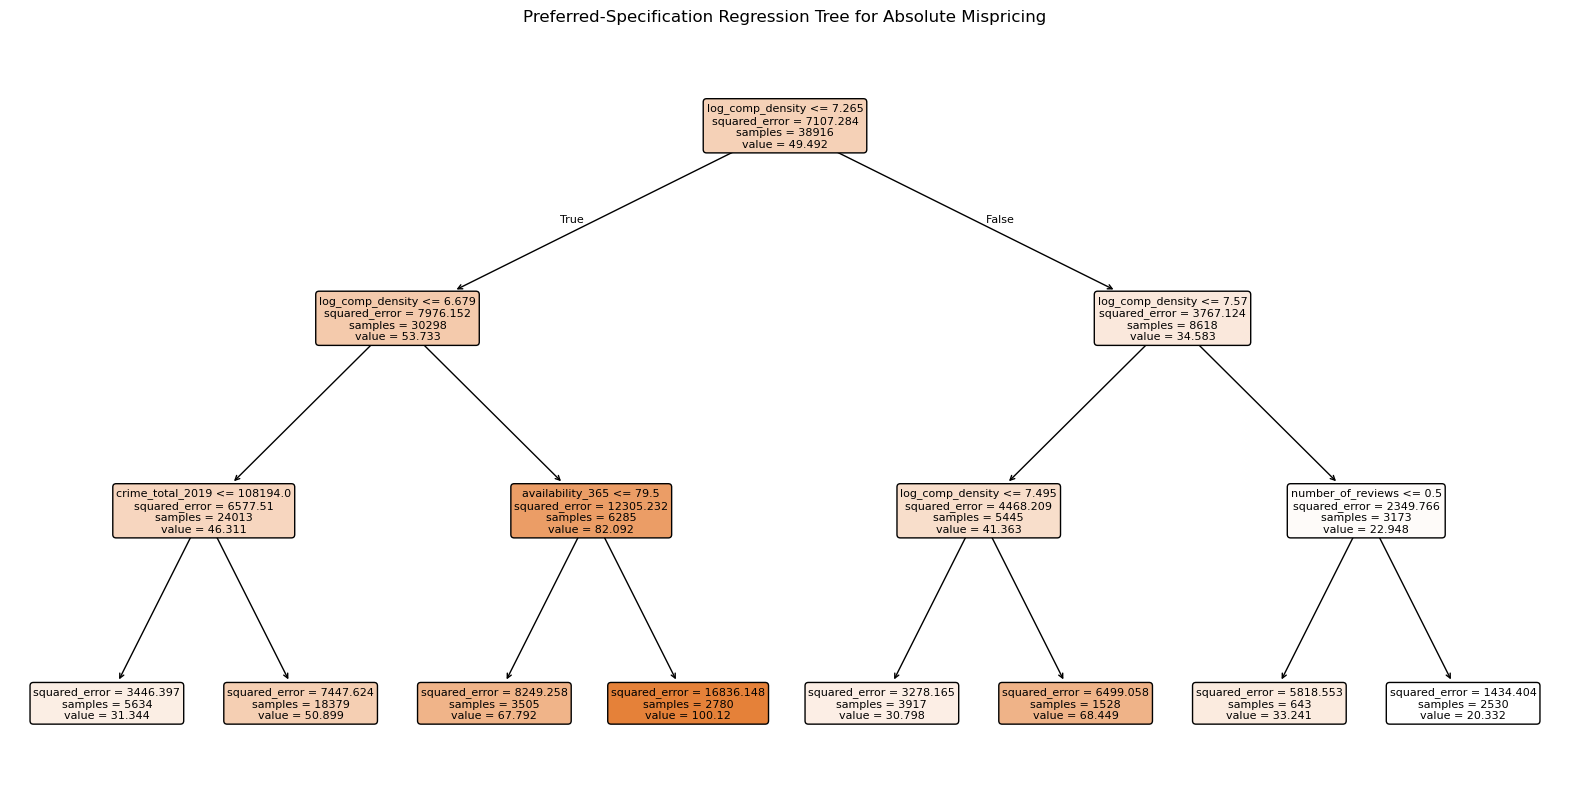

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Preferred-specification tree using the same X variables as the preferred OLS regression
tree_pref_df = df[
    [
        "mispricing_abs",
        "reviews_per_month",
        "log_comp_density",
        "minimum_nights",
        "availability_365",
        "number_of_reviews",
        "calculated_host_listings_count",
        "crime_total_2019",
        "log_nearest_subway_km"
    ]
].copy()

# Keep rows with non-missing outcome only
tree_pref_df = tree_pref_df.dropna(subset=["mispricing_abs"]).copy()

# Fill missing X values with medians
pref_num_cols = [
    "reviews_per_month",
    "log_comp_density",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "calculated_host_listings_count",
    "crime_total_2019",
    "log_nearest_subway_km"
]

for col in pref_num_cols:
    tree_pref_df[col] = tree_pref_df[col].fillna(tree_pref_df[col].median())

# Define X and y variables
X_pref = tree_pref_df.drop(columns=["mispricing_abs"])
y_pref = tree_pref_df["mispricing_abs"]

X_pref_train, X_pref_test, y_pref_train, y_pref_test = train_test_split(
    X_pref, y_pref, test_size=0.2, random_state=42
)

print("Preferred tree training shape:", X_pref_train.shape)
print("Preferred tree test shape:", X_pref_test.shape)

# Fit preferred regression tree
tree_pref_model = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=100,
    random_state=42
)

tree_pref_model.fit(X_pref_train, y_pref_train)

# Predictions
y_pref_pred = tree_pref_model.predict(X_pref_test)

# Metrics
tree_pref_mae = mean_absolute_error(y_pref_test, y_pref_pred)
tree_pref_rmse = np.sqrt(mean_squared_error(y_pref_test, y_pref_pred))
tree_pref_r2 = r2_score(y_pref_test, y_pref_pred)

print("Preferred-Specification Regression Tree Results")
print(f"MAE: {tree_pref_mae:.3f}")
print(f"RMSE: {tree_pref_rmse:.3f}")
print(f"R^2: {tree_pref_r2:.3f}")

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_pref_model,
    feature_names=X_pref.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Preferred-Specification Regression Tree for Absolute Mispricing")
plt.show()

The preferred-specification regression tree produces a relatively simple and interpretable set of splits. The first and second splits are both on log_comp_density, indicating that the clearest nonlinear predictor of absolute pricing inefficiency in the preferred variable set is the density of comparable listings in the local market. Economically, this suggests that listings in less dense comparable markets tend to exhibit higher pricing inefficiency, while listings in very dense comparable markets tend to be priced closer to their benchmark. This is consistent with the idea that denser markets provide clearer price signals.

Within the lower-density branches of the tree, additional splits occur on crime_total_2019 and availability_365, suggesting that once local price signals are weaker, broader borough conditions and listing availability become useful for separating lower-mispricing from higher-mispricing listings. One of the highest-predicted-mispricing terminal nodes is associated with lower comparable density and relatively high availability, which is consistent with the idea that listings with weaker demand or slower price updating may remain further from their benchmark. In the densest branch of the tree, number_of_reviews helps distinguish listings with lower versus higher mispricing, suggesting that accumulated market feedback may still matter once listings are already operating in clearer information environments.

In predictive terms, the preferred-specification tree yields an MAE of 43.073, an RMSE of 82.416, and an R² of 0.058 on the test sample. This indicates that the tree captures some nonlinear structure in pricing inefficiency, but overall explanatory power remains modest. That result is consistent with the broader findings of the paper: Airbnb pricing inefficiency is partly predictable, but still depends on many listing-specific and unobserved factors.

### Kitchen Sink Tree


In [204]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Keep only the variables of interest
tree_df = df[[
    "mispricing_abs",
    "reviews_per_month",
    "log_comp_density",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "calculated_host_listings_count",
    "crime_total_2019",
    "nearest_subway_km",
    "neighbourhood_group",
    "room_type"
]].copy()

# Drop any rows missing the outcome
tree_df = tree_df.dropna(subset=["mispricing_abs"])

# Fill missing numeric values with median
num_cols = [
    "reviews_per_month",
    "log_comp_density",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "calculated_host_listings_count",
    "crime_total_2019",
    "nearest_subway_km"
]

for col in num_cols:
    tree_df[col] = tree_df[col].fillna(tree_df[col].median())

# Fill missing categorical values with mode
tree_df["neighbourhood_group"] = tree_df["neighbourhood_group"].fillna(tree_df["neighbourhood_group"].mode()[0])
tree_df["room_type"] = tree_df["room_type"].fillna(tree_df["room_type"].mode()[0])

tree_df_encoded = pd.get_dummies(
    tree_df,
    columns=["neighbourhood_group", "room_type"],
    drop_first=True
)

# Define X and y 
X = tree_df_encoded.drop(columns=["mispricing_abs"])
y = tree_df_encoded["mispricing_abs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (38916, 14)
X_test shape: (9729, 14)


Single Kitchen-Sink Regression Tree Results
MAE:  41.434
RMSE: 81.076
R^2:  0.088


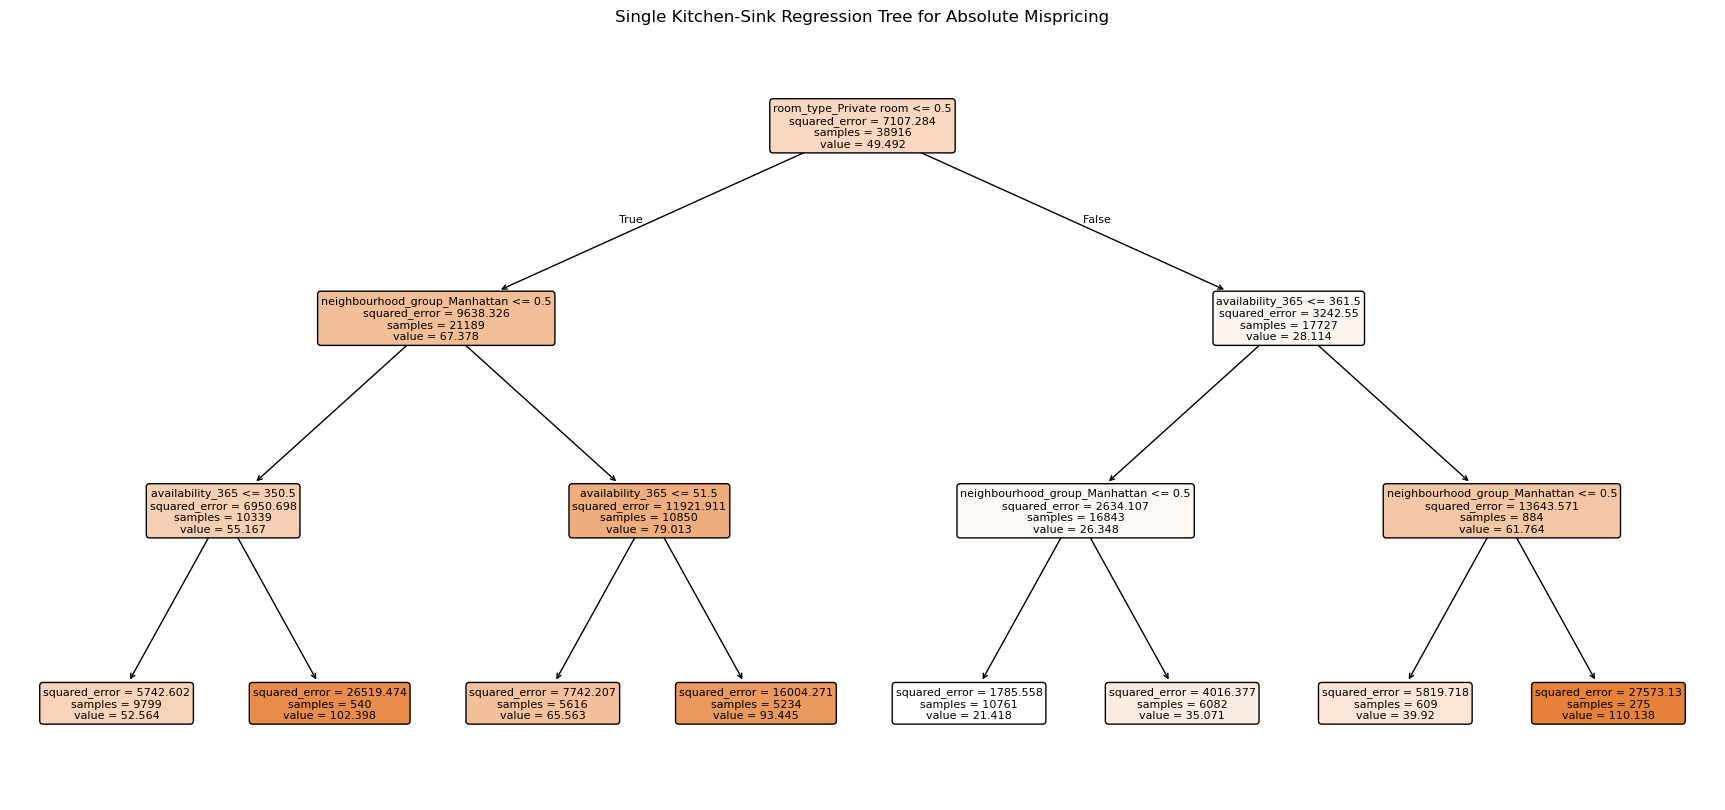

In [205]:
import matplotlib.pyplot as plt

# Single regression tree
tree_model = DecisionTreeRegressor(
    max_depth=3,          
    min_samples_leaf=100,
    random_state=42
)

tree_model.fit(X_train, y_train)

# predictions
y_pred_tree = tree_model.predict(X_test)

# metrics
tree_mae = mean_absolute_error(y_test, y_pred_tree)
tree_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
tree_r2 = r2_score(y_test, y_pred_tree)

print("Single Kitchen-Sink Regression Tree Results")
print(f"MAE:  {tree_mae:.3f}")
print(f"RMSE: {tree_rmse:.3f}")
print(f"R^2:  {tree_r2:.3f}")

# plot tree
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Single Kitchen-Sink Regression Tree for Absolute Mispricing")
plt.show()


The kitchen-sink regression tree produces a noticeably different set of splits from the preferred-specification tree. Once broader categorical variables are added, the first split is on room_type_Private room, and later splits depend heavily on neighbourhood_group_Manhattan and availability_365 rather than beginning with log_comp_density. Economically, this suggests that when the model is allowed to use a wider set of predictors, the strongest threshold-style differences in absolute pricing inefficiency come from listing type and broad location rather than from comparable-listing density alone. In particular, non-private-room listings tend to have higher predicted mispricing than private rooms, and Manhattan listings tend to remain more mispriced than similar listings elsewhere. Availability also plays an important role within these branches, with very highly available listings often ending up in the highest-mispricing terminal nodes, which is consistent with the idea that weaker demand or slower price adjustment may leave some listings further from their benchmark.  

In predictive terms, the kitchen-sink tree improves on the preferred-specification tree. Its MAE falls to 41.434 from 43.073, its RMSE falls to 81.076 from 82.416, and its R² rises to 0.088 from 0.058. This means that adding room-type and borough indicators helps the tree explain more of the variation in pricing inefficiency, although overall predictive power remains modest. Relative to the preferred tree, the kitchen-sink tree is less centered on market-density thresholds and more centered on broad structural differences across listing types and locations. That comparison is useful because it suggests that nonlinear pricing inefficiency is shaped not only by market-signal clarity, but also by basic categorical features such as room type and whether the listing is in Manhattan.  

## 3.6 Random Forest

In [206]:
# random forest regressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# predictions
y_pred_rf = rf_model.predict(X_test)

# metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print(f"MAE:  {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R^2:  {rf_r2:.3f}")

Random Forest Results
MAE:  38.711
RMSE: 76.180
R^2:  0.195


room_type_Private room               2.283141e-01
availability_365                     1.620256e-01
number_of_reviews                    1.016038e-01
log_comp_density                     9.863118e-02
minimum_nights                       9.717851e-02
calculated_host_listings_count       8.677466e-02
nearest_subway_km                    7.520981e-02
neighbourhood_group_Manhattan        6.351573e-02
reviews_per_month                    4.579549e-02
room_type_Shared room                3.796344e-02
crime_total_2019                     1.670215e-03
neighbourhood_group_Queens           7.242772e-04
neighbourhood_group_Brooklyn         5.926282e-04
neighbourhood_group_Staten Island    6.368479e-07
dtype: float64


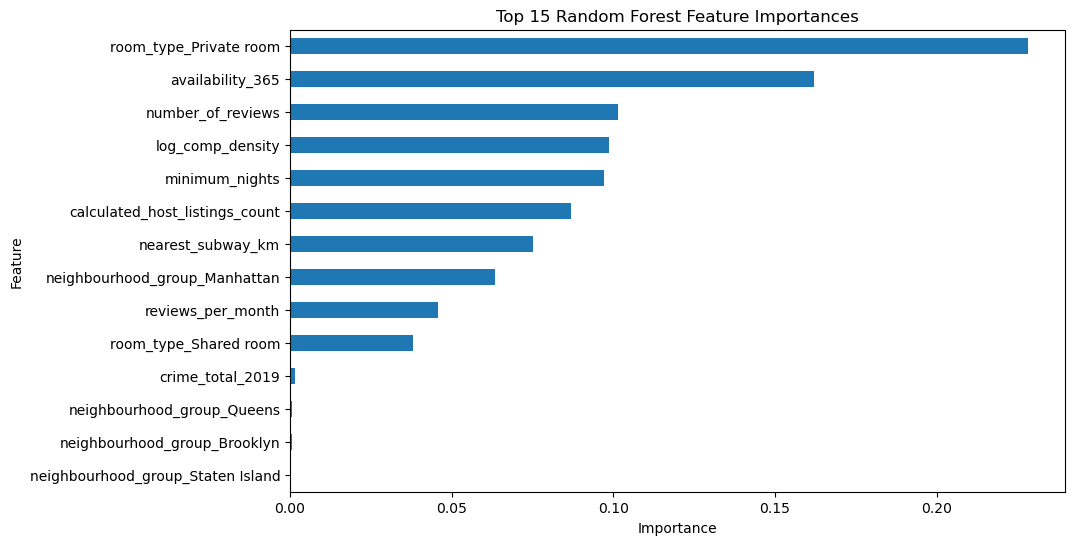

In [207]:
# feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_importance = rf_importance.sort_values(ascending=False)

print(rf_importance.head(15))

plt.figure(figsize=(10, 6))
rf_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("rf_feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()

The random forest improves predictive performance relative to both regression trees. On the test sample, it yields an MAE of 38.711, an RMSE of 76.180, and an R² of 0.195, which is better than both the preferred-specification tree and the kitchen-sink tree. This suggests that allowing the model to average across many trees captures more nonlinear structure in Airbnb pricing inefficiency than a single tree can. Even so, the overall R² remains modest, which indicates that a large share of listing-level pricing inefficiency is still driven by factors that are either unobserved or difficult to predict precisely.  

The feature-importance matrix also provides useful economic insight. The most important predictors are room_type_Private room, availability_365, number_of_reviews, log_comp_density, minimum_nights, and calculated_host_listings_count, while reviews_per_month is important but not among the top few predictors. This is interesting because it suggests that although review intensity was central in the OLS analysis, the broader prediction problem is influenced even more by listing type, availability, accumulated reviews, and market structure. In other words, the random forest suggests that pricing inefficiency is shaped not only by ongoing feedback flow, but also by more persistent structural differences across listings and locations. 

## 3.7 OLS vs ML


The OLS and machine-learning models are useful for different reasons in this project. The OLS regressions are most helpful for testing the paper’s main hypothesis in a transparent way. In particular, OLS gives directly interpretable coefficients on review intensity, comparable-listing density, and their interaction, which makes it possible to assess whether more reviews are associated with lower pricing inefficiency and whether that relationship changes across market environments. This is the main strength of the linear regression framework: it provides a clear coefficient-based answer to the economic question, even if overall explanatory power remains modest. In my results, the preferred OLS specification shows a negative and statistically significant relationship between review intensity and absolute mispricing, while the interaction term suggests that this relationship becomes weaker rather than stronger in denser comparable markets.  

The regression-tree models add information that OLS cannot show as easily. A tree does not impose one constant linear relationship for the whole sample. Instead, it identifies cutoffs in the explanatory variables and allows different groups of listings to follow different prediction rules. In my preferred-specification tree, the first major splits are on log_comp_density, which suggests that the clearest nonlinear structure in mispricing comes from thresholds in comparable-listing density rather than from one global marginal effect. In the kitchen-sink tree, the first split changes to room_type_Private room, and later splits rely heavily on neighbourhood_group_Manhattan and availability_365. This shows that once broader listing-type and location variables are added, the strongest nonlinear differences in pricing inefficiency are driven less by review intensity alone and more by room type, borough, and listing availability.

The random forest extends this logic by averaging across many trees and therefore improving predictive performance. In my results, the random forest outperforms both single-tree models, with an MAE of 38.711, an RMSE of 76.180, and an R² of 0.195. Its importance matrix shows that room_type_Private room, availability_365, number_of_reviews, log_comp_density, and minimum_nights are among the most important predictors, while reviews_per_month remains relevant but is not one of the top-ranked variables. Economically, this suggests that pricing inefficiency is influenced not only by ongoing feedback flow, which was central in the OLS discussion, but also by broader structural differences across listing type, availability, accumulated reputation, and local market conditions.  

Taken together, the OLS and ML results are complementary rather than contradictory. OLS is better for coefficient interpretation and hypothesis testing, while the tree-based models are better for revealing nonlinear thresholds, heterogeneous relationships, and stronger predictive patterns. The main message of the paper still survives this comparison: review activity is associated with lower pricing inefficiency on average. However, the machine-learning results suggest that the broader prediction problem is shaped even more by listing type, availability, and market structure than a simple linear model would imply. This is the main extra information extracted from the tree-based models that was not as visible in the OLS framework.

## 3.8 Conclusion
This project examined whether (and to what extent) greater Airbnb review intensity is associated with lower pricing inefficiency in New York City listings. Using absolute pricing inefficiency as the absolute deviation from the neighbourhood-by-room-type benchmark price, the descriptive figures, maps, and OLS regressions all point to the same broad conclusion: listings with higher review intensity tend to be priced closer to their local benchmark on average. In the regression analysis, this relationship remains negative and statistically significant across the core specifications, suggesting that review activity is associated with modest but meaningful improvements in pricing efficiency. The OLS regression results help answer the question of extent, implying that one additional review per month is associated with roughly 0.85 to 2.66 dollars lower absolute mispricing depending on specification, so the magnitude of the relationship is economically modest rather than dramatic. The nonlinear specifications point in the same direction. In the logged-review model, doubling reviews per month is associated with roughly 1.7 dollars lower absolute mispricing, while the log-log specification implies that a 10 percent increase in review intensity is associated with about a 1 percent decrease in absolute mispricing, and doubling review intensity is associated with about a 6.7 percent decrease in mispricing. By contrast, the quadratic review specification provides only weak evidence of simple polynomial nonlinearity. At the same time, the positive interaction between reviews per month and log comparable listing density suggests that the review–mispricing relationship becomes weaker rather than stronger in denser comparable markets, meaning the proposed market-density mechanism is not supported.  

The spatial and scraping sections add useful context to these results. The MODZCTA maps show that mispricing, review intensity, comparable-listing density, and transit access all vary across space, with the clearest urban-core pattern appearing in comparable-listing density and subway access. The scraped hotel data further show that hotels are generally more expensive than Airbnb across boroughs, especially in Manhattan and Brooklyn, which suggests that Airbnb hosts operate within a broader accommodation market where the outside option is often substantially more expensive. Together, these sections suggest that pricing inefficiency is shaped not only by review-based learning within Airbnb, but also by broader local market structure and accommodation-market conditions.  

The machine-learning models extend this picture by showing that the broader prediction problem is more complex than a single linear relationship. The preferred regression tree highlights thresholds in comparable-listing density, while the kitchen-sink tree shifts attention toward room type, Manhattan location, and availability. The random forest performs best of the three ML models, with an MAE of 38.711, an RMSE of 76.180, and an R² of 0.195, and its importance ranking suggests that room type, availability, accumulated reviews, comparable-listing density, and host scale are among the strongest predictors of pricing inefficiency. This means that the main OLS message still survives, which is that more review activity is associated with lower mispricing on average, but the tree-based models show that structural listing characteristics and market context matter even more for prediction than the linear regression alone would suggest.  

Overall, the evidence suggests that more frequent review activity is associated with lower Airbnb pricing inefficiency in NYC, but the size of that relationship is modest and depends on market conditions. The main finding of the paper is therefore supported, while the proposed density-amplification mechanism is not. A useful direction for future work would be to incorporate richer listing-level quality measures, more granular neighbourhood controls, and repeated hotel-price snapshots over time, which could help separate persistent structural drivers of mispricing from short-run market conditions.



## References
Abrate, G., Sainaghi, R., & Mauri, A. G. (2022). Dynamic pricing in Airbnb: Individual versus professional hosts. Journal of Business Research, 142, 191–199. https://doi.org/10.1016/j.jbusres.2021.12.012


Bárcena-Martín, E., Benítez-Aurioles, B., & Pérez-Moreno, S. (2023). Peer-to-peer accommodation prices: City listing concentration and host listing share. *Tourism Economics, 29*(6), 1499–1519. https://doi.org/10.1177/13548166221110526


Bernardi, M., & Guidolin, M. (2023). The determinants of Airbnb prices in New York City: A spatial quantile regression approach. Journal of the Royal Statistical Society: Series C (Applied Statistics), 72(1), 106–143. https://doi.org/10.1093/jrsssc/qlad001


Boto-García, D., Mayor, M., & De la Vega, P. (2021). Spatial price mimicking on Airbnb: Multi-host vs single-host. *Tourism Management, 87*, Article 104365. https://doi.org/10.1016/j.tourman.2021.104365


Ert, E., Fleischer, A., & Magen, N. (2016). Trust and reputation in the sharing economy: The role of personal photos in Airbnb. Tourism Management, 55, 62–73. https://doi.org/10.1016/j.tourman.2016.01.013


Gyódi, K., & Nawaro, Ł. (2021). Determinants of Airbnb prices in European cities: A spatial econometrics approach. *Tourism Management, 86*, Article 104319. https://doi.org/10.1016/j.tourman.2021.104319


Lawani, A., Reed, M. R., Mark, T., & Zheng, Y. (2019). Reviews and price on online platforms: Evidence from sentiment analysis of Airbnb reviews in Boston. *Regional Science and Urban Economics, 75*, 22–34. https://doi.org/10.1016/j.regsciurbeco.2018.11.003


Lin, W., & Yang, F. (2024). The price of short-term housing: A study of Airbnb on 26 regions in the United States. *Journal of Housing Economics, 65*, Article 102005. https://doi.org/10.1016/j.jhe.2024.102005


Mayya, R., Ye, S., Viswanathan, S., & Agarwal, R. (2021). Who forgoes screening in online markets and why? Evidence from Airbnb. MIS Quarterly, 45(4), 1745–1776. https://doi.org/10.25300/MISQ/2021/15335

Proserpio, D., Xu, W., & Zervas, G. (2018). You get what you give: Theory and evidence of reciprocity in the sharing economy. *Quantitative Marketing and Economics, 16*(4), 371–407. https://doi.org/10.1007/s11129-018-9201-9


Voltes-Dorta, A. (2025). Price competition among short-term Airbnb listings in New York City following Local Law 18. Current Issues in Tourism, 28(13), 2047–2051. https://doi.org/10.1080/13683500.2024.2354521


Zhao, H. (2023). Influence of built environment features on Airbnb listing price and the spatio-temporal heterogeneity: An empirical study from Copenhagen, Denmark. Geografisk Tidsskrift-Danish Journal of Geography, 123(1), 42–60. https://doi.org/10.1080/00167223.2023.2275037

dgomonov. (2019). New York City Airbnb Open Data [Data set]. Kaggle. Retrieved January 23, 2026, from https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data


New York City Police Department. (n.d.). NYPD Complaint Data Historic [Data set]. NYC Open Data (via data.gov). Retrieved January 30, 2026, from https://catalog.data.gov/dataset/nypd-complaint-data-historic


NYC Environment and Health Data Portal. (n.d.). MODZCTA_2010_WGS1984.geo.json [GeoJSON file]. GitHub. Retrieved March 13, 2026, from https://github.com/nycehs/NYC_geography/blob/master/MODZCTA_2010_WGS1984.geo.json


Metropolitan Transportation Authority. (n.d.). MTA Subway Stations and Complexes [Data set]. Open NY. Retrieved March 13, 2026, from https://data.ny.gov/Transportation/MTA-Subway-Stations-and-Complexes/5f5g-n3cz

Hotels.com. (n.d.). New York City hotel search results [Hotel listing search results]. Retrieved April 7, 2026, from hotels.com
